In [1]:
"""Sticky HDP-AR-HMM states of the CA1 LFP, against the manifold embeddings.

Three cells.

CELL 1  definitions only — config, the sampler, the loaders, the scoring and
        the figures. Runs nothing, so it is the thing that becomes a module
        once this settles.
CELL 2  surveys the recordings: units per region and cell type, and how
        typical each one's reconstruction is.
CELL 3  takes a recording name and does the work. OBS_SPEC lives here — what
        the AR-HMM is trained on, how each input is smoothed, whether it is
        z-scored. That is the thing being tinkered with, so it sits with the
        run: change it, re-run the cell, look at the observation plot, repeat.

The states are defined on the CA1 LFP's band power together with the
multi-unit activity of each region's cell-type populations, at the LFP's own
sampling rate rather than the 50 ms manifold grid — a state boundary is a
physical event, and binning it to 50 ms before looking for it throws away the
thing being measured. OBS_SPEC decides exactly which traces go in.

The embeddings are not refit here. They are read back from the cache that
reconstruction_error_test.py wrote, so this is fast and the geometry it plots
is exactly the geometry that was scored there. Those were fit on every unit in
the recording, which is why the MUA covers every region too: the manifold is
not a CA1 object even when the LFP is.

What CELL 3 does
    1. rebuild the session's 50 ms bin grid exactly as the sweep did, and
       check it against the cached embeddings before using them
    2. build the observation traces from OBS_SPEC and show them, so the inputs
       can be looked at before an hour is spent sampling
    3. fit the sticky HDP-AR-HMM, with the number of states inferred
    4. elbow plots: the eigenvalue spectrum of each embedding, and this
       recording's own reconstruction curve against dimensions
    5. rank each method's components by what dropping one does to held-out
       reconstruction MSE — not by eigenvalue order, which is a smoothness
       ordering for Laplacian eigenmaps and means nothing for reconstruction
    6. plot the manifolds and the top-ranked components against position,
       speed and band power, coloured by inferred state, and one example
       window with everything on a shared time axis

Nothing is written to disk. Everything is print() and plt.show().

Two things to keep in mind.

Resolution. PCA was fit on every bin, kernel PCA and Laplacian eigenmaps on
every tenth (they build an n x n matrix and cannot take 50k bins). So the
Laplacian embedding exists at 500 ms and the PCA one at 50 ms. The example
window draws anything coarser than one bin as markers, to keep that visible
rather than hiding it behind interpolation.

Coverage. The model is fitted on RUN_MINUTES of data, taken as several
segments placed at random one per equal block of the recording, so it spans
the session rather than one corner of it. Each segment gets its own design
matrix and its own pass of the state sampler, and transitions are not counted
across the joins. Bins outside the segments carry no state label and the
manifold figures draw them grey.

Cost. An iteration goes as samples x L x (n_lags * d + 1)^2, quadratic in the
AR order and the number of observations — that is what separates this from a
plain HMM. OBS_SPEC sets lag_span_s and n_lags; their ratio is the sampling
step everything is built on.
"""

# %% ===========================================================================
# CELL 1 — config, the sampler, the loaders, the scoring, the figures
# ==============================================================================
# Definitions only. Running this cell loads nothing and fits nothing.

import gc
import re
import time
from copy import deepcopy
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
import scipy.signal as sps
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.fft import next_fast_len
from scipy.linalg import solve_triangular
from scipy.stats import invwishart
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------

DOWNLOAD_DIR = Path("/storage/dandi_downloads").resolve()

# Written by reconstruction_error_test.py. Must be the z-scored cache: the
# embeddings and the activity matrix rebuilt below have to agree on scaling or
# the reconstruction numbers mean nothing.
CACHE_DIR = Path("/storage/manifold_embeddings_zscoreddata")

# --- these four must match the sweep that filled CACHE_DIR --------------------
BIN_SIZE_S = 0.050
RATE_TRANSFORM = "zscore"
MIN_RATE_HZ = 0.0
EPOCH = "maze"

# --- where things live in the unit metadata -----------------------------------
REGION_FIELD = "cell_area"
CELL_TYPE_FIELD = "cell_type"
FOCUS_REGION = "CA1"        # whose LFP is used; the MUA covers every region

# --- LFP band colours ---------------------------------------------------------
# The bands themselves are set in OBS_SPEC in CELL 3 and passed to
# load_session from there, so adding or moving one is a single edit in the
# cell being run. This is only the palette; a band name not listed here draws
# in grey, which is cosmetic and does not stop anything.
BAND_COLORS = {
    "low_theta": "#2ca02c",
    "high_theta": "#1f77b4",
    "theta": "#2ca02c",
    "beta": "#8c564b",
    "slow_gamma": "#ff7f0e",
    "gamma": "#ff7f0e",
    "mid_gamma": "#e377c2",
    "ripple": "#c2338f",
}
# Regions and cell types get fixed colours so they read the same in every
# figure and across recordings. Anything unlisted falls back to grey.
REGION_COLORS = {
    "CA1": "#d62728",
    "CA3": "#1f77b4",
    "RSC": "#2ca02c",
    "unknown": "0.6",
    "all": "0.4",
}
# Keyed on what this dandiset actually writes in `cell_type`, lowercased:
# "Pyramidal Cell", "Narrow Interneuron", "Wide Interneuron", "Unknown".
# The bare aliases are for other datasets.
CELL_TYPE_COLORS = {
    "pyramidal cell": "#8c564b", "pyramidal": "#8c564b", "pyr": "#8c564b",
    "excitatory": "#8c564b", "exc": "#8c564b",
    "narrow interneuron": "#17becf", "narrow": "#17becf",
    "wide interneuron": "#9467bd", "wide": "#9467bd",
    "interneuron": "#17becf", "int": "#17becf", "inhibitory": "#17becf",
    "inh": "#17becf",
    "unknown": "0.6",
}
# Order and abbreviations for the survey figures and tables. Anything not
# listed sorts after these, under its own name.
CELL_TYPE_ORDER = ("Pyramidal Cell", "Narrow Interneuron", "Wide Interneuron",
                   "Unknown")
CELL_TYPE_SHORT = {"pyramidal cell": "Pyr", "narrow interneuron": "NarrowInt",
                   "wide interneuron": "WideInt", "unknown": "Unk"}
# Cell type is drawn as a shade of its region's colour plus a hatch, so the
# two variables stay separable without needing eight distinct hues.
CELL_TYPE_HATCH = ("", "///", "...", "xx", "\\\\", "++")
# Cosmetic only. A region or cell type nobody assigned a colour still gets
# drawn, in grey — this is the one place a default is right, because the
# alternative is a figure that refuses to render over a palette entry.
FALLBACK_COLOR = "0.5"

# Which LFP series to take. pick_lfp_key raises rather than settling for a
# different region, since every figure here says CA1.
LFP_REGION_HINT = "ca1"

# What the AR-HMM is trained on lives in CELL 3, next to the rest of the run
# knobs — it is the thing being tinkered with, so it sits with the run and not
# here. build_observations() documents the keys.

# --- the AR-HMM ---------------------------------------------------------------
# At 1250 Hz an AR order of 1 is a 0.8 ms lag, which is a very local question;
# raise ARHMM_NLAGS to let the model see further back, at linear cost in the
# design matrix.
ARHMM_MINUTES = 10.0      # total data to fit; None = the whole epoch
ARHMM_SEGMENT_S = 60.0    # length of each randomly placed segment
ARHMM_SEGMENT_SEED = 0    # which random placement
ARHMM_START_S = None      # a number = one contiguous window there instead
ARHMM_NLAGS = 1
ARHMM_L = 20              # truncation level; raise if K_hat hits it
ARHMM_MAX_ITER = 100      # ceiling; the run stops earlier once stationary
ARHMM_BURN_IN = 25        # must be < max_iter or nothing is retained
ARHMM_EARLY_STOP = True
ARHMM_CHECK_EVERY = 10    # how often stationarity is tested, and reported
ARHMM_GEWEKE_TOL = 2.0    # |z| below this counts as stationary
ARHMM_ALPHA = 1.0
ARHMM_KAPPA = 50.0        # sticky bias: bigger = longer dwell times
ARHMM_GAMMA = 1.0
ARHMM_MIN_FRAC = 0.01     # a state is "used" if it holds >= 1% of samples
ARHMM_SEED = 0

# --- component ranking --------------------------------------------------------
# Rank by what dropping a component does to held-out reconstruction MSE, which
# is the only ordering that means anything across all three methods: PCA and
# kernel PCA come out in eigenvalue order, but Laplacian eigenmaps come out in
# ascending graph-Laplacian order, which is smoothness, not importance.
K_LLE = 10
LAMBDA = 1.0
RANK_DIMS = 15            # the working set a component is dropped from
RANK_FOLDS = 5
RANK_MAX_SAMPLES = 4000
RANK_SEED = 0
TOP_N = 3                 # components carried into the figures

METHODS = ("PCA", "KernelPCA", "Laplacian")
METHOD_COLORS = {"PCA": "#1f77b4", "KernelPCA": "#d62728",
                 "Laplacian": "#9467bd"}
MAP_METHODS = ("PCA", "KernelPCA", "Laplacian")  # which get the 3d figures
MAP_MAX_POINTS = 12000                           # scatter subsample

ELBOW_DIMS = 40           # x-limit of the scree and reconstruction elbows

EXAMPLE_WINDOW_S = 8.0
SUGGEST_N = 6             # how many recordings to list as candidates


def region_colour(name):
    return REGION_COLORS.get(str(name), FALLBACK_COLOR)


def cell_type_colour(name):
    return CELL_TYPE_COLORS.get(str(name).strip().lower(), FALLBACK_COLOR)


def cell_type_short(name):
    return CELL_TYPE_SHORT.get(str(name).strip().lower(), str(name))


def cell_type_sort(present):
    """CELL_TYPE_ORDER first, then anything else alphabetically."""
    known = [c for c in CELL_TYPE_ORDER if c in set(present)]
    return known + sorted(set(present) - set(known))


def shade(colour, fraction):
    """`colour` mixed toward white. fraction 0 = unchanged, 1 = white."""
    r, g, b = mcolors.to_rgb(colour)
    return (r + (1 - r) * fraction, g + (1 - g) * fraction,
            b + (1 - b) * fraction)


def label_axis(ax, labels, axis="x", rotation=0, fontsize=7):
    """Put one tick per category, centred on its cell.

    imshow indexes cells 0..n-1, so matplotlib's automatic locator picks round
    numbers like 2.5 and lands them between cells. Anything drawn on a
    categorical axis has to set its ticks explicitly.
    """
    ticks = np.arange(len(labels))
    text = [str(v) for v in labels]
    if axis == "x":
        ax.set_xticks(ticks)
        ax.set_xticklabels(text, rotation=rotation, fontsize=fontsize,
                           ha="right" if rotation not in (0, 90) else "center")
    else:
        ax.set_yticks(ticks)
        ax.set_yticklabels(text, fontsize=fontsize)


def show_table(frame, floats=None):
    """Render a frame as a notebook table, or print it outside one.

    The wide survey tables are unreadable as monospace text at this width.
    This is a check on what the runtime can render, not a fallback for missing
    data — the frame is the same either way.
    """
    try:
        from IPython.display import display
    except ImportError:
        print(frame.to_string(float_format=floats))
        return
    display(frame if floats is None else frame.style.format(floats))


def observation_colour(name, kind):
    """One colour rule for every observation trace, wherever it is drawn."""
    if kind == "band":
        return BAND_COLORS.get(name, FALLBACK_COLOR)
    parts = name.split("_")
    return cell_type_colour(parts[-1]) if len(parts) >= 3 else FALLBACK_COLOR


# -----------------------------------------------------------------------------
# THE STICKY HDP-AR-HMM
# -----------------------------------------------------------------------------
# Fox, Sudderth, Jordan & Willsky (2009). An autoregressive HMM with a
# hierarchical Dirichlet process prior over the transition matrix, so the
# number of states is inferred rather than fixed:
#
#     beta        ~ GEM(gamma)
#     pi_j        ~ DP(alpha + kappa, (alpha*beta + kappa*delta_j)/(alpha+kappa))
#     z_t | z_t-1 ~ pi_{z_t-1}
#     y_t         = A_{z_t} [y_{t-1}, ..., y_{t-r}, 1] + e_t,  e_t ~ N(0, Sigma)
#     (A_k, Sigma_k) ~ Matrix-Normal-Inverse-Wishart
#
# kappa is the sticky self-transition bias, which stops the model explaining
# the data with rapidly switching redundant states. Inference is a blocked
# Gibbs sampler under the weak-limit approximation of the DP: truncate at L
# states, and the ones that end up holding (almost) no data are unused.
#
# The script as supplied, with three changes, all so it can fit several
# disjoint stretches of a recording rather than one contiguous block:
#   - the synthetic-data and evaluation part is dropped
#   - Y is a list of segments, each with its own design matrix, so no row
#     regresses on samples from a different part of the session
#   - the state sampler runs per segment and transition counts skip the joins
#
# Cost per iteration is dominated by the MNIW step, which forms a p x p Gram
# matrix per state with p = nlags * d + 1: samples x L x p^2. Quadratic in the
# AR order and in the number of observations, which is what separates this
# from a plain HMM — that has no regression at all.


def make_design(Y, nlags):
    """Build lagged design matrix X (with bias column) and targets Y[nlags:]."""
    T, d = Y.shape
    lags = [Y[nlags - l - 1: T - l - 1] for l in range(nlags)]
    X = np.hstack(lags + [np.ones((T - nlags, 1))])
    return X, Y[nlags:]


def stack_designs(segments, nlags):
    """One design matrix per segment, stacked, plus where each one starts.

    Building the lags per segment is the point: a single design over the
    concatenation would regress the first rows of each segment on the last
    samples of the one before it, which are minutes away.
    """
    Xs, Ys, starts, n = [], [], [], 0
    for seg in segments:
        if len(seg) <= nlags:
            raise ValueError(f"a segment of {len(seg)} samples cannot support "
                             f"nlags={nlags}")
        X, Yt = make_design(seg, nlags)
        Xs.append(X)
        Ys.append(Yt)
        starts.append(n)
        n += len(Yt)
    return np.vstack(Xs), np.vstack(Ys), np.array(starts, dtype=int)


def sample_mniw(X, Y, M0, K0, S0, nu0, rng):
    """Sample (A, Sigma) from the MNIW posterior given regressors X, targets Y.

    With no data (X empty) this samples from the prior.
    """
    Sxx = X.T @ X + K0
    Syx = Y.T @ X + M0 @ K0
    Syy = Y.T @ Y + M0 @ K0 @ M0.T
    Sxx_inv = np.linalg.inv(Sxx)
    Sxx_inv = (Sxx_inv + Sxx_inv.T) / 2
    Mn = Syx @ Sxx_inv
    Sn = S0 + Syy - Mn @ Syx.T
    Sn = (Sn + Sn.T) / 2 + 1e-9 * np.eye(Sn.shape[0])
    nun = nu0 + X.shape[0]

    Sigma = np.atleast_2d(invwishart.rvs(df=nun, scale=Sn, random_state=rng))
    L_sig = np.linalg.cholesky(Sigma)
    L_col = np.linalg.cholesky(Sxx_inv)
    A = Mn + L_sig @ rng.standard_normal(Mn.shape) @ L_col.T
    return A, Sigma


def ar_loglik(X, Y, A, Sigma):
    """Per-timestep Gaussian log-likelihood of Y under AR params (A, Sigma)."""
    d = Y.shape[1]
    R = Y - X @ A.T
    L = np.linalg.cholesky(Sigma)
    sol = solve_triangular(L, R.T, lower=True)
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    return -0.5 * (d * np.log(2 * np.pi) + logdet + np.sum(sol ** 2, axis=0))


def sample_states(logL, P, pi0, rng, starts=None):
    """Blocked sampling of the state sequence (backward filter, forward sample).

    `starts` marks where each segment begins. Each one is filtered and sampled
    on its own and drawn from pi0 at its first sample, because a segment's
    opening state has no predecessor — the sample before it in the array is
    from somewhere else in the recording.
    """
    T, L = logL.shape
    bounds = np.append(np.array([0]) if starts is None else starts, T)
    z = np.empty(T, dtype=int)
    for lo, hi in zip(bounds[:-1], bounds[1:]):
        z[lo:hi] = _sample_states_one(logL[lo:hi], P, pi0, rng)
    return z


def _sample_states_one(logL, P, pi0, rng):
    T, L = logL.shape
    lik = np.exp(logL - logL.max(axis=1, keepdims=True))
    bwd = np.ones((T, L))
    for t in range(T - 2, -1, -1):
        b = P @ (lik[t + 1] * bwd[t + 1])
        bwd[t] = b / (b.sum() + 1e-300)

    u = rng.random(T)
    z = np.empty(T, dtype=int)
    p = pi0 * lik[0] * bwd[0]
    c = np.cumsum(p)
    z[0] = min(np.searchsorted(c, u[0] * c[-1]), L - 1)
    for t in range(1, T):
        p = P[z[t - 1]] * lik[t] * bwd[t]
        c = np.cumsum(p)
        z[t] = min(np.searchsorted(c, u[t] * c[-1]), L - 1)
    return z


def safe_dirichlet(a, rng):
    g = rng.gamma(np.maximum(a, 1e-12)) + 1e-300
    return g / g.sum()


def sample_tables(N, alpha, kappa, beta, rng):
    """Chinese-restaurant-franchise table counts m_jk."""
    L = len(beta)
    M = np.zeros((L, L), dtype=int)
    for j in range(L):
        for k in range(L):
            n = int(N[j, k])
            if n == 0:
                continue
            conc = alpha * beta[k] + (kappa if j == k else 0.0)
            M[j, k] = np.sum(rng.random(n) < conc / (conc + np.arange(n)))
    return M


def sample_beta(N, alpha, kappa, gamma, beta, rng):
    """Resample global weights via auxiliary tables + sticky override variables."""
    L = len(beta)
    M = sample_tables(N, alpha, kappa, beta, rng)
    rho = kappa / (alpha + kappa)
    w = rng.binomial(np.diag(M), rho / (rho + beta * (1 - rho)))
    Mbar = M.copy()
    Mbar[np.diag_indices(L)] -= w
    return safe_dirichlet(gamma / L + Mbar.sum(axis=0), rng)


def sample_transitions(N, alpha, kappa, beta, rng):
    L = len(beta)
    P = np.empty((L, L))
    for j in range(L):
        a = alpha * beta + N[j]
        a[j] += kappa
        P[j] = safe_dirichlet(a, rng)
    return P


def effective_sample_size(x):
    """Number of independent draws a correlated chain is worth.

    n / tau with tau = 1 + 2 sum_k rho_k, truncated by Geyer's initial
    positive sequence: the autocorrelations are summed in adjacent pairs and
    the sum stops at the first pair that goes negative.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 8:
        return float(n)
    centred = x - x.mean()
    spectrum = np.fft.rfft(centred, 2 * n)
    acf = np.fft.irfft(spectrum * np.conj(spectrum))[:n].real
    if acf[0] <= 0:
        return float(n)
    acf /= acf[0]
    pair = acf[1:n - 1:2] + acf[2:n:2]
    negative = np.flatnonzero(pair < 0)
    cut = int(negative[0]) if negative.size else len(pair)
    tau = 1.0 + 2.0 * acf[1:2 * cut + 1].sum()
    return float(n / max(tau, 1e-6))


def geweke_z(x, first=0.1, last=0.5):
    """Geweke's z for the difference in mean between the head and tail.

    Under stationarity the two means estimate the same quantity, so the
    difference over its standard error is approximately N(0, 1). The standard
    errors use the effective sample size rather than the raw length, because
    successive Gibbs draws are correlated.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    head = x[:max(int(first * n), 2)]
    tail = x[-max(int(last * n), 2):]
    se = np.sqrt(head.var(ddof=1) / effective_sample_size(head)
                 + tail.var(ddof=1) / effective_sample_size(tail))
    if se <= 0:
        return 0.0
    return float((head.mean() - tail.mean()) / se)


def convergence_report(trace_ll, trace_K, burn_in, tol=2.0):
    """Whether the retained part of the chain looks stationary.

    Three numbers. The Geweke z compares the first tenth of the retained
    log-likelihood against the last half. The drift is the least-squares slope
    across the retained window, expressed as a multiple of the trace's own
    standard deviation, so a value near zero means the chain is no longer
    climbing. The state count is the fraction of retained iterations sitting
    at the modal K.
    """
    ll = np.asarray(trace_ll[burn_in:], dtype=float)
    kk = np.asarray(trace_K[burn_in:], dtype=int)
    if len(ll) < 8:
        raise ValueError(f"only {len(ll)} retained iterations — too few to "
                         f"say anything about stationarity")
    it = np.arange(len(ll), dtype=float)
    slope = np.polyfit(it, ll, 1)[0]
    drift = slope * len(ll) / (ll.std(ddof=1) + 1e-12)
    modal = np.bincount(kk).argmax()
    return {"geweke_z": geweke_z(ll),
            "drift_sd": float(drift),
            "ess": effective_sample_size(ll),
            "K_modal": int(modal),
            "K_stable_frac": float((kk == modal).mean()),
            "stationary": bool(abs(geweke_z(ll)) < tol and abs(drift) < 1.0
                               and (kk == modal).mean() > 0.9)}


def fit_hdp_arhmm(Y, nlags=ARHMM_NLAGS, L=ARHMM_L, max_iter=ARHMM_MAX_ITER,
                  burn_in=ARHMM_BURN_IN, alpha=ARHMM_ALPHA, kappa=ARHMM_KAPPA,
                  gamma=ARHMM_GAMMA, min_frac=ARHMM_MIN_FRAC, standardize=True,
                  seed=ARHMM_SEED, stop_when_stationary=ARHMM_EARLY_STOP,
                  check_every=ARHMM_CHECK_EVERY, geweke_tol=ARHMM_GEWEKE_TOL,
                  verbose=True):
    """
    Y        : (T, d) array, or a list of them — one per contiguous segment
    nlags    : AR order r
    L        : truncation level (max number of states)
    max_iter : ceiling on Gibbs iterations; the run may stop earlier
    burn_in  : iterations discarded before any sample is retained
    alpha    : transition concentration
    kappa    : sticky self-transition bias (bigger = longer state durations)
    gamma    : top-level DP concentration (bigger = more states a priori)
    min_frac : a state counts as "used" if it holds >= this fraction of timesteps

    stop_when_stationary checks every `check_every` iterations past burn_in and
    stops once the Geweke z on the retained log-likelihood is under
    geweke_tol, the least-squares drift across that window is under one of its
    standard deviations, and the used-state count has not moved in the last
    check. Without it the run always goes to max_iter.
    """
    if not 0 <= burn_in < max_iter:
        raise ValueError(
            f"burn_in={burn_in} must be at least 0 and less than "
            f"max_iter={max_iter}; as given, no iteration would be retained "
            f"and there would be nothing to compute a posterior from")
    rng = np.random.default_rng(seed)
    segments = [Y] if isinstance(Y, np.ndarray) else list(Y)
    segments = [np.atleast_2d(np.asarray(s, dtype=float).T).T
                if np.asarray(s).ndim == 1 else np.asarray(s, dtype=float)
                for s in segments]
    if standardize:
        # pooled over every segment, so the columns mean the same thing
        # wherever in the recording they came from
        pooled = np.vstack(segments)
        mu, sd = pooled.mean(0), pooled.std(0)
        segments = [(s - mu) / sd for s in segments]

    X, Yt, starts = stack_designs(segments, nlags)
    T, d = Yt.shape
    p = X.shape[1]
    # pairs of consecutive rows that sit inside one segment; the rest straddle
    # a join and are not transitions the chain ever made
    adjacent = np.ones(T - 1, dtype=bool)
    adjacent[starts[1:] - 1] = False

    # MNIW prior
    M0 = np.zeros((d, p))
    K0 = np.eye(p)
    nu0 = d + 2
    S0 = 0.1 * np.eye(d) * (nu0 - d - 1)

    # Initialise: random blocks of states
    block = 50
    z = np.repeat(rng.integers(0, L, size=T // block + 1), block)[:T]
    beta = np.ones(L) / L

    As = np.zeros((L, d, p))
    Sigmas = np.zeros((L, d, d))

    trace_K, trace_ll, z_samples = [], [], []
    converged, stopped_early = None, False
    started = time.perf_counter()
    for it in range(max_iter):
        # 1. AR parameters for each state
        for k in range(L):
            idx = z == k
            As[k], Sigmas[k] = sample_mniw(X[idx], Yt[idx], M0, K0, S0, nu0, rng)

        # 2. Transition counts -> beta and transition matrix. Only pairs
        #    inside a segment; a join is not a transition.
        N = np.zeros((L, L))
        np.add.at(N, (z[:-1][adjacent], z[1:][adjacent]), 1)
        beta = sample_beta(N, alpha, kappa, gamma, beta, rng)
        P = sample_transitions(N, alpha, kappa, beta, rng)

        # 3. State sequence, each segment filtered and sampled on its own
        logL = np.column_stack([ar_loglik(X, Yt, As[k], Sigmas[k]) for k in range(L)])
        z = sample_states(logL, P, beta, rng, starts)

        counts = np.bincount(z, minlength=L)
        K_used = int(np.sum(counts >= min_frac * T))
        ll = logL[np.arange(T), z].sum()
        trace_K.append(K_used)
        trace_ll.append(ll)
        if it >= burn_in:
            z_samples.append(z.copy())

        if verbose and (it % check_every == 0 or it == max_iter - 1):
            spent = time.perf_counter() - started
            left = spent / (it + 1) * (max_iter - it - 1)
            print(f"    iter {it:4d}/{max_iter} | used states {K_used:2d} | "
                  f"log-lik {ll:12.1f} | {spent / 60:.1f} min spent, "
                  f"<={left / 60:.1f} min left", flush=True)

        # Stationarity is checked on the retained part of the trace only, and
        # not until there are two check windows of it to compare.
        past_burn = it - burn_in + 1
        if (stop_when_stationary and past_burn >= 2 * check_every
                and past_burn % check_every == 0):
            converged = convergence_report(trace_ll, trace_K, burn_in,
                                           geweke_tol)
            if converged["stationary"]:
                stopped_early = True
                if verbose:
                    print(f"    stationary at iteration {it}: Geweke z="
                          f"{converged['geweke_z']:+.2f}, drift="
                          f"{converged['drift_sd']:+.2f} SD, K stable in "
                          f"{converged['K_stable_frac']:.0%} of retained "
                          f"iterations", flush=True)
                break

    n_run = len(trace_K)
    if converged is None:
        converged = convergence_report(trace_ll, trace_K, burn_in, geweke_tol)
    if verbose and not converged["stationary"]:
        print(f"    WARNING: not stationary after {n_run} iterations. "
              f"Geweke z={converged['geweke_z']:+.2f} (want |z| < {geweke_tol}), "
              f"drift={converged['drift_sd']:+.2f} SD (want |drift| < 1), "
              f"K stable in {converged['K_stable_frac']:.0%} (want > 90%). "
              f"Raise max_iter; the estimates below are what the chain had "
              f"reached, not what it would settle to.")

    post_K = np.array(trace_K[burn_in:])
    values, freq = np.unique(post_K, return_counts=True)
    K_hat = int(values[np.argmax(freq)])

    # Representative sample: highest log-lik post-burn-in sample with K_hat states
    cands = [i for i in range(burn_in, n_run) if trace_K[i] == K_hat]
    best = max(cands, key=lambda i: trace_ll[i])
    z_best = z_samples[best - burn_in]

    if verbose:
        print(f"    ran {n_run} of {max_iter} iterations"
              + (" (stopped early)" if stopped_early else "")
              + f" | retained {n_run - burn_in}, ESS "
                f"{converged['ess']:.0f}")
        print("    posterior over number of used states:")
        for v, f in zip(values, freq):
            print(f"      K = {v:2d}: {f / len(post_K):.2f}")
        print(f"    estimated number of states: {K_hat}")

    return dict(K_hat=K_hat, z=z_best, trace_K=np.array(trace_K),
                trace_ll=np.array(trace_ll), z_samples=z_samples,
                As=As, Sigmas=Sigmas, beta=beta, P=P, Y=Yt,
                segment_starts=starts, nlags=nlags, burn_in=burn_in,
                n_lag_terms=p, n_iterations=n_run,
                stopped_early=stopped_early, convergence=converged)


# -----------------------------------------------------------------------------
# SURVEYING THE RECORDINGS
# -----------------------------------------------------------------------------


def recording_table(root=DOWNLOAD_DIR):
    """Every NWB under the download directory, same ordering as the sweep."""
    rows = []
    for path in sorted(Path(root).rglob("*.nwb")):
        stem = path.stem
        subject = re.search(r"sub-([^_]+)", stem)
        session = re.search(r"ses-([^_]+)", stem)
        ses = session.group(1) if session else "unknown"
        rows.append({
            "subject": subject.group(1) if subject else path.parent.name,
            "session": ses,
            "date": f"{ses[:4]}-{ses[4:6]}-{ses[6:8]}" if len(ses) >= 8 else ses,
            "has_behavior": "behavior" in stem,
            "file": str(path.relative_to(root)),
        })
    return (pd.DataFrame(rows).sort_values(["subject", "session"])
            .reset_index(drop=True))


def unit_metadata(spike_group):
    """Region and cell type per unit, as a frame, with the gaps named."""
    meta = spike_group.metadata
    frame = pd.DataFrame(index=range(len(spike_group.index)))
    for field in (REGION_FIELD, CELL_TYPE_FIELD):
        if field not in meta.columns:
            raise KeyError(
                f"unit metadata has no {field!r} column — found "
                f"{list(meta.columns)}. Every region and cell type in this "
                f"script is read from that column, so there is nothing "
                f"sensible to proceed with.")
        frame[field] = meta[field].astype(str).values
    return frame


def unit_inventory(row, root=DOWNLOAD_DIR):
    """Units per region and cell type for one file, without binning anything."""
    path = (Path(root) / row["file"]).resolve()
    nwb = nap.load_file(str(path))
    meta = unit_metadata(nwb["units"])
    counts = (meta.groupby([REGION_FIELD, CELL_TYPE_FIELD])
              .size().rename("n").reset_index())
    counts.insert(0, "file", row["file"])
    counts.insert(0, "date", row["date"])
    counts.insert(0, "subject", row["subject"])
    del nwb
    gc.collect()
    return counts


def survey_units(recordings, root=DOWNLOAD_DIR, verbose=True):
    """Region x cell-type counts for every recording, long and wide.

    The wide table is indexed by "M01 2024-03-08" and its cell-type columns
    are abbreviated — the file path and the full type names made it several
    hundred characters across, which no terminal renders usefully.
    """
    frames = []
    for i, (_, row) in enumerate(recordings.iterrows(), start=1):
        if verbose:
            print(f"    [{i}/{len(recordings)}] {row['file']}", flush=True)
        frames.append(unit_inventory(row, root))
    long = pd.concat(frames, ignore_index=True)
    long["name"] = long["subject"] + " " + long["date"]

    wide = long.pivot_table(index="name",
                            columns=[REGION_FIELD, CELL_TYPE_FIELD],
                            values="n", aggfunc="sum", fill_value=0)
    order = [(r, c) for r in sorted({r for r, _ in wide.columns})
             for c in cell_type_sort([c for rr, c in wide.columns if rr == r])]
    wide = wide[order]
    wide.columns = pd.MultiIndex.from_tuples(
        [(r, cell_type_short(c)) for r, c in wide.columns])
    wide.insert(0, ("", "total"), wide.sum(axis=1))
    return long, wide


def load_scores(cache_dir=CACHE_DIR):
    """The sweep's per-fold reconstruction scores."""
    path = Path(cache_dir) / "results_scores.csv"
    if not path.exists():
        raise FileNotFoundError(
            f"{path} is missing — run reconstruction_error_test.py first, or "
            f"point CACHE_DIR at the folder its sweep filled")
    t0 = time.perf_counter()
    scores = pd.read_csv(path, usecols=["file", "method", "k", "rec_corr"])
    print(f"read {len(scores)} scored folds from {path.name} "
          f"({time.perf_counter() - t0:.1f}s)")
    return scores


def typicality(scores, max_k=30):
    """Distance of each recording's reconstruction curve from the average.

    The activity-reconstruction figure is corr(real, rebuilt) against number of
    dimensions, one curve per recording per method. This averages the folds,
    takes the mean curve across recordings as the reference, and scores each
    recording by its mean absolute departure from it. Small = typical.
    """
    curves = (scores[scores["k"] <= max_k]
              .groupby(["file", "method", "k"], as_index=False)["rec_corr"].mean())
    reference = (curves.groupby(["method", "k"], as_index=False)["rec_corr"]
                 .mean().rename(columns={"rec_corr": "mean_corr"}))
    merged = curves.merge(reference, on=["method", "k"])
    merged["gap"] = (merged["rec_corr"] - merged["mean_corr"]).abs()
    return (merged.groupby("file", as_index=False)
            .agg(distance_from_mean=("gap", "mean"),
                 mean_rec_corr=("rec_corr", "mean"))
            .sort_values("distance_from_mean").reset_index(drop=True))


def suggest_recordings(scores, recordings, units_long, n=SUGGEST_N,
                       require_behavior=True, focus=FOCUS_REGION, verbose=True):
    """Rank recordings by how typical their reconstruction is, with cell counts.

    Position and speed are needed throughout, so the ecephys-only files cannot
    be the example however typical their reconstruction looks. The focus
    region's unit count is printed alongside, because a session with four CA1
    cells has no CA1 MUA to speak of whatever its reconstruction curve does.
    """
    ranked = typicality(scores)
    ranked["has_behavior"] = ranked["file"].isin(
        set(recordings.loc[recordings["has_behavior"], "file"]))
    ranked = ranked.merge(recordings[["file", "subject", "date"]],
                          on="file", how="left")

    totals = units_long.groupby("file")["n"].sum().rename("units")
    focus_n = (units_long[units_long[REGION_FIELD] == focus]
               .groupby("file")["n"].sum().rename(f"{focus}_units"))
    groups = (units_long[units_long["n"] >= 3].groupby("file").size()
              .rename("mua_groups"))
    ranked = (ranked.merge(totals, on="file", how="left")
              .merge(focus_n, on="file", how="left")
              .merge(groups, on="file", how="left")
              .fillna({f"{focus}_units": 0, "mua_groups": 0}))

    eligible = (ranked[ranked["has_behavior"]] if require_behavior
                else ranked).reset_index(drop=True)
    eligible.insert(0, "name", eligible["subject"] + " " + eligible["date"])
    if verbose:
        print("\nrecordings closest to the mean reconstruction curve "
              "(k <= 30, averaged over methods and folds). mua_groups counts "
              "region x cell-type populations with >= 3 units.")
        show_table(
            eligible.head(n)[["name", "distance_from_mean", "mean_rec_corr",
                              "units", f"{focus}_units", "mua_groups"]]
            .set_index("name").round(4))
        dropped = ranked[~ranked["has_behavior"]]
        if require_behavior and len(dropped):
            print(f"excluded (no behaviour, so no position or speed): "
                  f"{', '.join(dropped['file'])}")
    return eligible


def plot_unit_survey(units_long, focus=FOCUS_REGION):
    """Units per recording: totals stacked by region, then split per region.

    Top: one bar per recording, stacked by region, so the sessions are
    comparable in size at a glance.

    Bottom: one group of bars per recording, one bar per region within it,
    each bar stacked by cell type. Colour is the region and the shading plus
    hatch is the cell type, which keeps the two variables separable — a single
    stacked bar in eight colours would be unreadable, and colouring by cell
    type alone throws the region away.
    """
    units_long = units_long.copy()
    if "name" not in units_long:
        units_long["name"] = units_long["subject"] + " " + units_long["date"]
    names = list(dict.fromkeys(units_long["name"]))
    regions = sorted(set(units_long[REGION_FIELD]))
    types = cell_type_sort(units_long[CELL_TYPE_FIELD])
    x = np.arange(len(names))

    fig, axes = plt.subplots(2, 1, figsize=(max(11, 1.1 * len(names)), 9),
                             sharex=True)
    fig.suptitle("units per recording, by region and by cell type")

    # --- top: totals, stacked by region --------------------------------------
    ax = axes[0]
    table = (units_long.pivot_table(index="name", columns=REGION_FIELD,
                                    values="n", aggfunc="sum", fill_value=0)
             .reindex(names))
    bottom = np.zeros(len(names))
    for region in regions:
        values = table[region].values
        ax.bar(x, values, bottom=bottom, color=region_colour(region),
               label=region)
        bottom += values
    focus_counts = (units_long[units_long[REGION_FIELD] == focus]
                    .groupby("name")["n"].sum().reindex(names).fillna(0))
    for xi, value in zip(x, focus_counts.values):
        ax.text(xi, bottom[xi] + 4, f"{int(value)}", ha="center", fontsize=7,
                color=region_colour(focus))
    ax.set_ylabel("units by region")
    ax.set_title(f"the number above each bar is the {focus} count", fontsize=9)
    ax.legend(fontsize=8, ncol=len(regions))

    # --- bottom: a bar per region, stacked by cell type ----------------------
    ax = axes[1]
    group_width = 0.78
    bar_width = group_width / len(regions)
    counts = (units_long.pivot_table(index=["name", REGION_FIELD],
                                     columns=CELL_TYPE_FIELD, values="n",
                                     aggfunc="sum", fill_value=0)
              .reindex(pd.MultiIndex.from_product([names, regions]),
                       fill_value=0))
    # shades run dark to light down CELL_TYPE_ORDER, so the commonest type
    # (pyramidal) is the solid base of each bar
    shades = np.linspace(0.0, 0.62, max(len(types), 1))
    for j, region in enumerate(regions):
        offset = (j - (len(regions) - 1) / 2) * bar_width
        base = region_colour(region)
        bottom = np.zeros(len(names))
        for t, cell_type in enumerate(types):
            values = np.array([counts.loc[(n, region)].get(cell_type, 0)
                               for n in names], dtype=float)
            ax.bar(x + offset, values, width=bar_width * 0.92, bottom=bottom,
                   color=shade(base, shades[t]),
                   hatch=CELL_TYPE_HATCH[t % len(CELL_TYPE_HATCH)],
                   edgecolor="white", linewidth=0.4)
            bottom += values
    ax.set_ylabel("units by region and cell type")
    ax.set_title("one bar per region within each recording; shading and hatch "
                 "are cell type", fontsize=9)

    region_keys = [Patch(facecolor=region_colour(r), label=r) for r in regions]
    type_keys = [Patch(facecolor=shade("0.35", shades[t]), edgecolor="white",
                       hatch=CELL_TYPE_HATCH[t % len(CELL_TYPE_HATCH)],
                       label=cell_type_short(c)) for t, c in enumerate(types)]
    first = ax.legend(handles=region_keys, fontsize=8, ncol=len(regions),
                      loc="upper right", title="region", title_fontsize=8)
    ax.add_artist(first)
    ax.legend(handles=type_keys, fontsize=8, ncol=len(types),
              loc="upper left", title="cell type", title_fontsize=8)

    label_axis(axes[-1], names, axis="x", rotation=60, fontsize=8)
    axes[-1].set_xlim(-0.6, len(names) - 0.4)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def resolve_recording(recordings, pattern):
    """The row for `pattern`. Ambiguous or missing patterns are an error."""
    matches = [f for f in recordings["file"] if pattern in f]
    if not matches:
        raise ValueError(f"RECORDING={pattern!r} matched none of the files")
    if len(matches) > 1:
        raise ValueError(f"RECORDING={pattern!r} matched {len(matches)}: "
                         + ", ".join(matches))
    print(f"RECORDING={pattern!r} -> {matches[0]}")
    return recordings[recordings["file"] == matches[0]].iloc[0]


# -----------------------------------------------------------------------------
# THE SESSION
# -----------------------------------------------------------------------------


def transform_rates(rates, how=RATE_TRANSFORM):
    """Identical to the sweep's: per unit, over the bins of this epoch."""
    if how == "none":
        return rates
    if how == "sqrt":
        return np.sqrt(rates)
    if how == "zscore":
        mu = rates.mean(axis=0, keepdims=True)
        sd = rates.std(axis=0, keepdims=True)
        return np.divide(rates - mu, sd, out=np.zeros_like(rates, dtype=np.float64),
                         where=sd > 1e-12)
    raise ValueError(f"unknown RATE_TRANSFORM: {how}")


def bandpass_sos(values, fs, lo, hi, order=4):
    """Zero-phase Butterworth bandpass in SOS form.

    SOS rather than b/a because the low bands sit at a fraction of a percent of
    Nyquist, where transfer-function coefficients are numerically fragile.
    """
    sos = sps.butter(order, [lo, hi], btype="band", fs=fs, output="sos")
    return sps.sosfiltfilt(sos, values)


def analytic_envelope(values):
    """Hilbert amplitude envelope, FFT-padded to a fast length."""
    n = len(values)
    return np.abs(sps.hilbert(values, N=next_fast_len(n)))[:n]


def bin_mean(sample_t, sample_v, edges):
    """Mean of a densely sampled signal within each bin, NaN where empty."""
    idx = np.searchsorted(edges, sample_t, side="right") - 1
    ok = (idx >= 0) & (idx < len(edges) - 1) & np.isfinite(sample_v)
    idx, vals = idx[ok], sample_v[ok]
    total = np.bincount(idx, weights=vals, minlength=len(edges) - 1)
    count = np.bincount(idx, minlength=len(edges) - 1)
    out = np.full(len(edges) - 1, np.nan)
    hit = count > 0
    out[hit] = total[hit] / count[hit]
    return out


def zscore(values):
    return (values - np.nanmean(values)) / (np.nanstd(values) + 1e-12)


def pick_lfp_key(nwb, hint=LFP_REGION_HINT, require_hint=True):
    """The LFP series whose name contains `hint`.

    require_hint=True because this analysis says "the CA1 LFP" everywhere, and
    falling back to whichever other channel happens to be first would make
    every figure a claim about a region nobody chose. Pass require_hint=False
    to take the only LFP there is, deliberately.
    """
    lfp_keys = [k for k in nwb.keys() if "lfp" in k.lower()]
    if not lfp_keys:
        raise KeyError("no LFP series in this file")
    preferred = [k for k in lfp_keys if hint in k.lower()]
    if preferred:
        return preferred[0], lfp_keys
    if require_hint:
        raise KeyError(
            f"no LFP series names {hint!r} — found {lfp_keys}. Set "
            f"LFP_REGION_HINT to one of those, or call with "
            f"require_hint=False to accept {lfp_keys[0]!r} as the channel.")
    return lfp_keys[0], lfp_keys


def load_session(row, bin_size_s=BIN_SIZE_S, epoch_mode=EPOCH,
                 transform=RATE_TRANSFORM, focus=FOCUS_REGION,
                 verbose=True):
    """Everything one recording needs, on two grids, before any spec is applied.

    The 50 ms grid is rebuilt exactly as reconstruction_error_test.load_session
    built it — same epoch, same edges, same unit filter — because the cached
    embeddings are indexed into it and nothing downstream would notice a quiet
    disagreement. That grid carries the activity matrix and the behaviour.

    The LFP grid carries the raw trace and the pooled spike times of every
    region x cell-type population. No filtering happens here — that is
    filter_bands(), called from CELL 3 with the ranges in OBS_SPEC, so the
    frequencies can be changed without reloading the file.
    """
    path = (DOWNLOAD_DIR / row["file"]).resolve()
    t0 = time.perf_counter()
    nwb = nap.load_file(str(path))
    spikes_all = nwb["units"]
    meta = unit_metadata(spikes_all)

    # "maze" is the position-tracked span, "full" the whole recording. A file
    # with no Position cannot supply a maze epoch, and quietly widening to the
    # full recording would change what every later number is about, so it is an
    # error: pass epoch_mode="full" if that is what you meant.
    if epoch_mode == "maze":
        position_all = nwb["Position"]
        epoch = nap.IntervalSet(start=float(position_all.index[0]),
                                end=float(position_all.index[-1]))
    elif epoch_mode == "full":
        starts = [spikes_all[u].index[0] for u in spikes_all.index if len(spikes_all[u])]
        ends = [spikes_all[u].index[-1] for u in spikes_all.index if len(spikes_all[u])]
        epoch = nap.IntervalSet(start=float(min(starts)), end=float(max(ends)))
    else:
        raise ValueError(f"epoch_mode must be 'maze' or 'full', got {epoch_mode!r}")
    epoch_kind = epoch_mode

    spikes = spikes_all.restrict(epoch)
    t_start, t_end = float(epoch.start[0]), float(epoch.end[0])
    edges = np.arange(t_start, t_end, bin_size_s)
    centers = edges[:-1] + bin_size_s / 2

    spike_times = [np.sort(np.asarray(spikes[u].index.values, dtype=np.float64))
                   for u in spikes.index]
    counts = np.empty((len(edges) - 1, len(spike_times)), dtype=np.float32)
    for j, st in enumerate(spike_times):
        counts[:, j] = np.diff(np.searchsorted(st, edges))
    rates = counts / bin_size_s
    keep = rates.mean(axis=0) > MIN_RATE_HZ
    rates = rates[:, keep]

    regions = meta[REGION_FIELD].values[keep]
    cell_types = meta[CELL_TYPE_FIELD].values[keep]
    kept_times = [st for st, k in zip(spike_times, keep) if k]

    X = np.asarray(transform_rates(rates, transform), dtype=np.float64)
    del rates, counts, spike_times
    gc.collect()

    # --- behaviour, on the 50 ms grid ----------------------------------------
    position = nwb["Position"].restrict(epoch)
    pos_t = np.asarray(position.index.values, dtype=float)
    pos_x = np.asarray(position["x"].values, dtype=float)
    pos_y = np.asarray(position["y"].values, dtype=float)
    speed_obj = nwb["Speed"].restrict(epoch)
    speed_t = np.asarray(speed_obj.index.values, dtype=float)
    speed_v = np.asarray(speed_obj.values, dtype=float).ravel()

    track_x = bin_mean(pos_t, pos_x, edges)
    track_y = bin_mean(pos_t, pos_y, edges)
    speed = bin_mean(speed_t, speed_v, edges)

    # --- LFP, at its own sampling rate ---------------------------------------
    lfp_key, lfp_keys = pick_lfp_key(nwb)
    lfp_obj = nwb[lfp_key].restrict(epoch)
    lfp_t = np.asarray(lfp_obj.index.values, dtype=np.float64)
    lfp_v = np.asarray(lfp_obj.values, dtype=np.float64).ravel()
    fs = float(1.0 / np.median(np.diff(lfp_t)))

    # --- pooled spike times per region x cell type ---------------------------
    mua_groups, mua_units = {}, {}
    for region in sorted(set(regions)):
        for cell_type in sorted(set(cell_types[regions == region])):
            sel = (regions == region) & (cell_types == cell_type)
            key = f"MUA_{region}_{cell_type}"
            mua_groups[key] = np.sort(np.concatenate(
                [st for st, s in zip(kept_times, sel) if s]))
            mua_units[key] = int(sel.sum())

    half = 0.5 / fs
    session = {
        "label": f"{row['subject']} {row['date']}", "file": row["file"],
        "epoch_kind": epoch_kind, "t_start": t_start, "t_end": t_end,
        "bin_size_s": bin_size_s, "edges": edges, "centers": centers,
        "X": X, "regions": regions, "cell_types": cell_types,
        "n_units": X.shape[1], "n_bins": X.shape[0],
        "track_x": track_x, "track_y": track_y, "speed": speed,
        "mua_groups": mua_groups, "mua_units": mua_units, "focus": focus,
        "lfp_v": lfp_v, "lfp_t": lfp_t,
        "lfp_edges": np.concatenate((lfp_t - half, [lfp_t[-1] + half])),
        "fs": fs, "lfp_key": lfp_key, "lfp_keys": lfp_keys,
        "rate_transform": transform,
    }
    del spikes, spikes_all, nwb, kept_times
    gc.collect()

    if verbose:
        print(f"loaded {row['file']} in {time.perf_counter() - t0:.1f}s")
        print(f"    {epoch_kind} epoch {(t_end - t_start) / 60:.1f} min | "
              f"{session['n_units']} units | {session['n_bins']} bins at "
              f"{bin_size_s * 1e3:.0f} ms | {len(lfp_t)} LFP samples at "
              f"{fs:.0f} Hz")
        inventory = (pd.DataFrame({REGION_FIELD: regions,
                                   CELL_TYPE_FIELD: cell_types})
                     .groupby([REGION_FIELD, CELL_TYPE_FIELD]).size()
                     .rename("units").reset_index())
        print("\nunits kept, by region and cell type")
        show_table(inventory.set_index([REGION_FIELD, CELL_TYPE_FIELD]))
        print(f"\nLFP: {lfp_key} @ {fs:.0f} Hz"
              + (f"  (of {len(lfp_keys)}: {', '.join(lfp_keys)})"
                 if len(lfp_keys) > 1 else "")
              + ("" if LFP_REGION_HINT in lfp_key.lower()
                 else f"  [no '{LFP_REGION_HINT}' in the name — check this is "
                      f"{focus}]"))
        print("raw LFP held; run filter_bands() next")
    return session


def filter_bands(session, bands, verbose=True):
    """Bandpass the raw LFP and take the Hilbert envelope, band by band.

    Its own step because the frequency ranges are part of what is being
    tinkered with. Call it again with different ranges and it refilters from
    the raw trace the session is still holding — no reload, no stale envelope
    computed under an earlier set of numbers.

    Adds to `session`: band_env (Hilbert amplitude), band_filt (the filtered
    signal itself), bands (the names, in order), power_summary, and
    power_z_bins — the envelopes binned to 50 ms and z-scored, which is not a
    model input but what the covariate scatters plot against.
    """
    t0 = time.perf_counter()
    lfp_v, lfp_t, fs = session["lfp_v"], session["lfp_t"], session["fs"]
    nyquist = fs / 2

    band_env, band_filt, rows = {}, {}, []
    for name, (lo, hi) in bands.items():
        if not 0 < lo < hi < nyquist:
            raise ValueError(
                f"band {name!r} = ({lo}, {hi}) Hz is not a usable range at "
                f"{fs:.0f} Hz — need 0 < low < high < {nyquist:.0f}")
        filt = bandpass_sos(lfp_v, fs, lo, hi)
        env = analytic_envelope(filt)
        band_env[name] = env.astype(np.float32)
        band_filt[name] = filt.astype(np.float32)
        rows.append({"band": name, "range_hz": f"{lo:g}-{hi:g}",
                     "median": float(np.median(env)),
                     "mean": float(env.mean()),
                     "p95": float(np.percentile(env, 95)),
                     "sd": float(env.std())})
        del filt, env
        gc.collect()

    session["bands"] = list(bands)
    session["band_env"] = band_env
    session["band_filt"] = band_filt
    session["power_summary"] = pd.DataFrame(rows)
    session["power_z_bins"] = {
        name: zscore(bin_mean(lfp_t, env.astype(np.float64), session["edges"]))
        for name, env in band_env.items()}

    if verbose:
        print(f"\nfiltered {len(bands)} bands in "
              f"{time.perf_counter() - t0:.1f}s "
              f"(raw envelope amplitude, before the spec's log or z-score)")
        show_table(session["power_summary"].set_index("band").round(3))
    return session


# -----------------------------------------------------------------------------
# BUILDING THE OBSERVATIONS THE AR-HMM SEES
# -----------------------------------------------------------------------------


def smoothing_kernel(spec, fs):
    """The kernel a smoothing spec asks for, normalized to sum to one.

    "gaussian"      symmetric, centred: averages equally over before and after
    "half_gaussian" causal: the right half only, so the value at t depends on
                    t and earlier and nothing later. A state boundary is not
                    smeared backwards before the model has a chance to find it.
    "boxcar"        flat, causal, sigma_s wide

    spec=None means no smoothing, which is a choice rather than a gap, so it
    is the one case that returns without a kernel.
    """
    if spec is None:
        return None
    kind = spec.get("kind", "gaussian")
    sigma = float(spec["sigma_s"]) * fs
    if sigma <= 0:
        raise ValueError(f"sigma_s={spec['sigma_s']} gives {sigma} samples at "
                         f"{fs:.0f} Hz — use smooth=None for no smoothing "
                         f"rather than a zero-width kernel")
    if kind == "boxcar":
        width = max(int(round(sigma)), 1)
        return np.ones(width, dtype=np.float64) / width
    radius = max(int(round(4 * sigma)), 1)
    if kind == "gaussian":
        offsets = np.arange(-radius, radius + 1, dtype=np.float64)
    elif kind == "half_gaussian":
        offsets = np.arange(0, radius + 1, dtype=np.float64)
    else:
        raise ValueError(f"unknown smoothing kind: {kind!r}")
    kernel = np.exp(-0.5 * (offsets / sigma) ** 2)
    return kernel / kernel.sum()


def smooth_trace(values, fs, spec):
    """Apply a smoothing spec, keeping the length and the time alignment."""
    kernel = smoothing_kernel(spec, fs)
    values = np.asarray(values, dtype=np.float64)
    if kernel is None:
        return values
    if spec.get("kind", "gaussian") == "gaussian":
        # symmetric kernel: centred, so the output at i uses both sides of i
        return np.convolve(values, kernel, mode="same")
    # causal kernels: the output at i uses i and earlier only. Edge-pad with
    # the first sample so the opening of the trace is not pulled toward zero.
    padded = np.concatenate((np.full(len(kernel) - 1, values[0]), values))
    return np.convolve(padded, kernel, mode="valid")[:len(values)]


def resample_trace(values, source_t, target_edges, method="median"):
    """Aggregate a densely sampled trace into the target bins.

    method is the statistic that stands for the bin: "median" is robust to the
    spikes an envelope carries at event onsets, "mean" weights them in, "max"
    keeps the largest excursion, "sum" integrates. Empty bins are NaN.
    """
    idx = np.searchsorted(target_edges, source_t, side="right") - 1
    n = len(target_edges) - 1
    ok = (idx >= 0) & (idx < n) & np.isfinite(values)
    idx, vals = idx[ok], np.asarray(values, dtype=np.float64)[ok]
    out = np.full(n, np.nan)
    if method == "median":
        grouped = pd.Series(vals).groupby(idx).median()
        out[grouped.index.values] = grouped.values
        return out
    if method == "sum":
        return np.bincount(idx, weights=vals, minlength=n)
    if method == "max":
        filled = np.full(n, -np.inf)
        np.maximum.at(filled, idx, vals)
        hit = np.isfinite(filled)
        out[hit] = filled[hit]
        return out
    if method != "mean":
        raise ValueError(f"unknown bin_method: {method!r} — use median, mean, "
                         f"max or sum")
    total = np.bincount(idx, weights=vals, minlength=n)
    count = np.bincount(idx, minlength=n)
    hit = count > 0
    out[hit] = total[hit] / count[hit]
    return out


def finish_trace(name, values, transform, do_zscore):
    """The last two steps every observation goes through, in that order.

    transform is None, "log1p" (needs values >= 0, and log1p(x) ~ x when
    x << 1) or "log10" (needs values > 0). A trace that violates the domain
    says so rather than being clamped to a floor.
    """
    values = np.asarray(values, dtype=np.float64)
    if transform == "log1p":
        if values.min() < 0:
            raise ValueError(
                f"{name}: log1p needs values >= 0, found {values.min():.4g}")
        values = np.log1p(values)
    elif transform == "log10":
        if not (values > 0).all():
            raise ValueError(
                f"{name}: log10 needs values > 0, but {(values <= 0).sum()} of "
                f"{len(values)} are not (min {values.min():.4g}). A filtered "
                f"LFP is signed and a smoothed spike count can be zero.")
        values = np.log10(values)
    elif transform is not None:
        raise ValueError(f"{name}: unknown transform {transform!r} — use "
                         f"None, 'log1p' or 'log10'")
    return zscore(values) if do_zscore else values


def build_observations(session, spec, verbose=True):
    """Turn the session's raw ingredients into the matrix the AR-HMM sees.

    The grid comes from the two lag settings: n_lags steps spanning
    lag_span_s means one step is lag_span_s / n_lags, so the rate is
    n_lags / lag_span_s. Those are what the AR-HMM is then fitted at.

    Bands go: envelope -> smooth -> median within each bin -> transform ->
    z-score. MUA goes: count in each bin -> divide by that population's total
    spikes -> smooth -> transform -> z-score. z-scoring is last either way, so
    every column enters the model on equal terms.

    The spec (OBS_SPEC in CELL 3):
        lag_span_s  total time the AR lags reach back
        n_lags      steps across that span
        bin_method  the statistic standing for each bin, for bands
        bands
          measure   "envelope" is the Hilbert amplitude, "power" its square,
                    "filtered" the oscillation itself
          smooth    None, or {"kind": "gaussian"|"half_gaussian"|"boxcar",
                    "sigma_s": seconds}. half_gaussian is causal.
          transform None, "log1p" or "log10", applied before z-scoring
          zscore    per trace, over the whole epoch, last
        mua
          groups    a list of (region, cell type) pairs, one pooled trace
                    each. None means every pair this recording has; a pair it
                    lacks raises rather than being skipped.
          min_units pairs smaller than this are reported and not used
          normalize "total_spikes" divides each trace by that population's
                    own spike count, so it is the share of its spikes falling
                    in each bin and empty bins are 0
          smooth    not optional in practice: without a kernel the counts are
                    a near-binary train
    """
    spec = deepcopy(spec)
    fs = session["fs"]
    lfp_t = session["lfp_t"]

    # --- the grid, from the lag settings -------------------------------------
    lag_span_s = float(spec["lag_span_s"])
    n_lags = int(spec["n_lags"])
    if lag_span_s <= 0 or n_lags < 1:
        raise ValueError(f"lag_span_s={lag_span_s} and n_lags={n_lags} must be "
                         f"positive")
    rate = n_lags / lag_span_s
    if rate > fs:
        raise ValueError(
            f"{n_lags} lags across {lag_span_s * 1e3:.0f} ms needs {rate:.0f} "
            f"Hz, above the LFP's {fs:.0f} Hz. Lengthen lag_span_s or use "
            f"fewer lags.")
    native = abs(rate - fs) < 1e-6
    if native:
        target_t, target_edges = lfp_t, None
    else:
        step = 1.0 / rate
        target_edges = np.arange(session["t_start"], session["t_end"], step)
        target_t = target_edges[:-1] + step / 2

    columns, names, kinds, notes = [], [], [], []

    band_spec = spec.get("bands", {})
    if band_spec.get("use", True):
        measure = band_spec.get("measure", "envelope")
        for name in band_spec.get("bands", session["bands"]):
            if name not in session["band_env"]:
                raise KeyError(
                    f"OBS_SPEC asks for band {name!r}, which was not filtered "
                    f"at load time — the session has {list(session['band_env'])}. "
                    f"Re-run load_session with the current "
                    f"OBS_SPEC['bands']['bands'].")
            if measure == "envelope":
                raw = session["band_env"][name].astype(np.float64)
            elif measure == "power":
                raw = session["band_env"][name].astype(np.float64) ** 2
            elif measure == "filtered":
                raw = session["band_filt"][name].astype(np.float64)
            else:
                raise ValueError(f"unknown band measure: {measure!r}")
            trace = smooth_trace(raw, fs, band_spec.get("smooth"))
            if not native:
                trace = resample_trace(trace, lfp_t, target_edges,
                                       spec.get("bin_method", "median"))
            columns.append(finish_trace(name, trace,
                                        band_spec.get("transform"),
                                        band_spec.get("zscore", True)))
            names.append(name)
            kinds.append("band")
            notes.append(f"{measure}, smooth="
                         f"{_smooth_label(band_spec.get('smooth'))}, "
                         f"{spec.get('bin_method', 'median')} per bin")
            del raw, trace
            gc.collect()

    mua_spec = spec.get("mua", {})
    if mua_spec.get("use", True):
        # `groups` is a list of (region, cell type) pairs, so CA1 pyramidal
        # and CA3 interneurons can be asked for without dragging in CA1
        # interneurons and CA3 pyramidal. None means every pair present.
        wanted = mua_spec.get("groups")
        min_units = int(mua_spec.get("min_units", 3))
        edges_for_counts = (session["lfp_edges"] if native else target_edges)
        available = session["mua_groups"]

        if wanted is None:
            keys = list(available)
        else:
            keys, absent = [], []
            for pair in wanted:
                region, cell_type = pair
                key = f"MUA_{region}_{cell_type}"
                (keys if key in available else absent).append(key)
            if absent:
                raise KeyError(
                    "OBS_SPEC['mua']['groups'] names pairs this recording does "
                    "not have: "
                    + ", ".join(a.replace("MUA_", "") for a in absent)
                    + ". It has: "
                    + ", ".join(f"{k.replace('MUA_', '')} ({v})"
                                for k, v in available.items()))

        selected = [k for k in keys if session["mua_units"][k] >= min_units]
        too_small = [k for k in keys if session["mua_units"][k] < min_units]
        if too_small and verbose:
            print(f"    under min_units={min_units}, not used: "
                  + ", ".join(f"{k.replace('MUA_', '')} "
                              f"({session['mua_units'][k]})"
                              for k in too_small))
        if wanted is not None and not selected:
            raise ValueError(
                f"every pair in OBS_SPEC['mua']['groups'] fell below "
                f"min_units={min_units}. This session has: "
                + ", ".join(f"{k.replace('MUA_', '')} ({v})"
                            for k, v in available.items()))

        normalize = mua_spec.get("normalize", "total_spikes")
        for key in selected:
            times = session["mua_groups"][key]
            counts = np.diff(np.searchsorted(times, edges_for_counts)).astype(np.float64)
            if normalize == "total_spikes":
                # column of counts divided by its own sum: the share of this
                # population's spikes landing in each bin. Empty bins are 0,
                # and a population that fires ten times as much as another no
                # longer enters the model ten times as large.
                total = counts.sum()
                if total <= 0:
                    raise ValueError(f"{key}: no spikes in the epoch, so it "
                                     f"cannot be normalized by its total")
                series = counts / total
            elif normalize is None:
                series = counts * rate          # spikes per second
            else:
                raise ValueError(f"unknown mua normalize: {normalize!r} — use "
                                 f"'total_spikes' or None")
            trace = smooth_trace(series, rate, mua_spec.get("smooth"))
            columns.append(finish_trace(key, trace, mua_spec.get("transform"),
                                        mua_spec.get("zscore", True)))
            names.append(key)
            kinds.append("mua")
            notes.append(f"{session['mua_units'][key]} units, "
                         f"{int(counts.sum())} spikes, norm={normalize}, "
                         f"smooth={_smooth_label(mua_spec.get('smooth'))}")
            del counts, series, trace
            gc.collect()

    if not columns:
        raise RuntimeError(
            "OBS_SPEC selected no observations — both 'bands' and 'mua' are "
            "off, or every population fell below min_units")

    Y = np.column_stack(columns)
    t = target_t

    # A constant or non-finite column carries nothing and makes Sigma
    # singular, so the sampler would fail later with a Cholesky error naming
    # no column. Name it here instead of dropping it: an observation that
    # turned out flat is a fact about the spec, and the spec is the thing to
    # change.
    bad = ~(np.isfinite(Y).all(axis=0) & (Y.std(axis=0) > 1e-9))
    if bad.any():
        raise ValueError(
            "these observations are constant or non-finite, which makes the "
            "AR covariance singular: "
            + ", ".join(f"{names[j]} (sd {Y[:, j].std():.3g}, "
                        f"{int((~np.isfinite(Y[:, j])).sum())} non-finite)"
                        for j in np.flatnonzero(bad))
            + ". Widen the smoothing kernel, drop them from OBS_SPEC, or "
              "raise min_units.")

    table = pd.DataFrame({"observation": names, "kind": kinds, "detail": notes,
                          "mean": Y.mean(axis=0), "sd": Y.std(axis=0),
                          "min": Y.min(axis=0), "max": Y.max(axis=0)})
    if verbose:
        print(f"\nobservations: {Y.shape[1]} traces x {Y.shape[0]} samples at "
              f"{rate:.0f} Hz ({n_lags} lags x {1e3 / rate:.1f} ms = "
              f"{lag_span_s * 1e3:.0f} ms of lag; LFP is {fs:.0f} Hz)")
        show_table(table.set_index("observation").round(3))
    return {"Y": Y, "names": names, "kinds": kinds, "t": t, "rate": rate,
            "nlags": n_lags, "lag_span_s": lag_span_s, "table": table,
            "spec": spec}


def _smooth_label(spec):
    if spec is None:
        return "none"
    return f"{spec.get('kind', 'gaussian')} {spec['sigma_s'] * 1e3:.0f}ms"


def plot_observations(session, obs, seconds=4.0, start_s=None):
    """What the AR-HMM is about to be trained on, as traces and as a matrix.

    Worth looking at before the sampler runs: a trace that is flat, clipped or
    dominated by one excursion will make states that are about that, and it
    takes an hour to find out the expensive way.
    """
    Y, names, kinds, t = obs["Y"], obs["names"], obs["kinds"], obs["t"]
    rate = obs["rate"]
    span = int(round(seconds * rate))
    if start_s is None:
        activity = np.abs(np.diff(Y, axis=0)).sum(axis=1)
        cumulative = np.concatenate(([0.0], np.cumsum(activity)))
        step = max(span // 4, 1)
        starts = np.arange(0, max(len(Y) - span, 1), step)
        first = int(starts[np.argmax(cumulative[np.minimum(starts + span - 1,
                                                           len(cumulative) - 1)]
                                     - cumulative[starts])])
    else:
        first = int(np.clip(np.searchsorted(t - session["t_start"], start_s),
                            0, max(len(Y) - span, 0)))
    seg = np.arange(first, min(first + span, len(Y)))

    fig, axes = plt.subplots(1, 2, figsize=(15, 0.55 * len(names) + 3),
                             gridspec_kw={"width_ratios": [2, 1]})
    fig.suptitle(f"{session['label']} — AR-HMM observations "
                 f"({len(names)} traces @ {rate:.0f} Hz)")

    ax = axes[0]
    offset = 0.0
    for j, (name, kind) in enumerate(zip(names, kinds)):
        trace = Y[seg, j]
        ax.plot(t[seg] - t[seg][0], trace + offset, lw=0.9,
                color=observation_colour(name, kind))
        ax.text(-0.01, offset, name.replace(f"MUA_", ""), fontsize=7,
                ha="right", va="center", transform=ax.get_yaxis_transform(),
                color=observation_colour(name, kind))
        offset -= 6.0
    ax.set_yticks([])
    ax.set_xlabel("time in window (s)")
    ax.set_title(f"{seconds:.1f} s from {t[first] - session['t_start']:.1f}s "
                 f"into the epoch (z, offset)", fontsize=9)

    ax = axes[1]
    corr = np.corrcoef(Y.T)
    off_diagonal = corr[~np.eye(len(names), dtype=bool)]
    limit = float(np.max(np.abs(off_diagonal)))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
    bar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    bar.set_label("Pearson r", fontsize=8)
    bar.ax.tick_params(labelsize=7)
    short = [n.replace("MUA_", "") for n in names]
    label_axis(ax, short, axis="x", rotation=90, fontsize=6)
    label_axis(ax, short, axis="y", fontsize=6)
    ax.set_title(f"observation correlation (scale from off-diagonal, "
                 f"|r| <= {limit:.2f})", fontsize=9)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


# -----------------------------------------------------------------------------
# THE CACHED EMBEDDINGS
# -----------------------------------------------------------------------------


def scale_embedding(Y, X):
    """Match the embedding's radius to the data's, as the sweep does.

    It matters because the LLE weights come from distances in embedding space:
    an embedding on a different scale changes the neighbourhood geometry the
    reconstruction depends on.
    """
    Yc = Y - np.mean(Y)
    rad_y = np.percentile(Yc, 95)
    rad_x = np.percentile(X - np.mean(X), 95)
    if not np.isfinite(rad_y) or abs(rad_y) < 1e-12:
        raise ValueError(
            f"the embedding's 95th-percentile radius is {rad_y!r}, so it "
            f"cannot be rescaled to the data. The embedding is degenerate — "
            f"refit it rather than reconstructing from it.")
    return (rad_x / rad_y) * Yc


def load_embedding(session, method, cache_dir=CACHE_DIR):
    """One cached embedding, checked against the session that was just rebuilt.

    A mismatch raises. An embedding fit on a different unit filter, bin size
    or scaling has rows that mean something else, and there is no version of
    "carry on without it" that leaves the figures meaning what they say.
    """
    stem = Path(session["file"]).stem
    path = Path(cache_dir) / (f"{stem}__{session['bin_size_s'] * 1e3:.0f}ms"
                              f"__{method}.npz")
    if not path.exists():
        raise FileNotFoundError(
            f"{path} — the sweep has not computed {method} for this recording "
            f"at {session['bin_size_s'] * 1e3:.0f} ms bins")
    with np.load(path, allow_pickle=False) as stored:
        Y = np.asarray(stored["embedding"], dtype=np.float64)
        idx = np.asarray(stored["idx_embed"], dtype=np.int64)
        n_units = int(stored["n_units"])
        transform = str(stored["rate_transform"])
    if n_units != session["n_units"]:
        raise ValueError(
            f"{path.name}: cached under {n_units} units, this session rebuilt "
            f"{session['n_units']}. The unit filter or the epoch has changed "
            f"since the sweep, so the embedding's rows are not these bins.")
    if idx.max() >= session["n_bins"]:
        raise ValueError(
            f"{path.name}: indexes bin {idx.max()} of {session['n_bins']}. "
            f"The bin size or the epoch differs from the sweep.")
    if transform != session["rate_transform"]:
        raise ValueError(
            f"{path.name}: fit under rate transform {transform!r}, this "
            f"session used {session['rate_transform']!r}. Point CACHE_DIR at "
            f"the matching cache.")
    return Y, idx, f"{Y.shape[0]} x {Y.shape[1]}, stride {int(np.median(np.diff(idx)))}"


def load_embeddings(session, methods=METHODS, cache_dir=CACHE_DIR, verbose=True):
    """Every cached embedding for this session, already scaled.

    Every method in `methods` must be present and must match. Pass a shorter
    `methods` to work with fewer, deliberately.
    """
    if verbose:
        print(f"\nembeddings from {cache_dir}")
    out = {}
    for method in methods:
        Y, idx, note = load_embedding(session, method, cache_dir)
        if verbose:
            print(f"    {method:10s} {note}")
        out[method] = {"Y": Y, "idx": idx,
                       "stride": int(np.median(np.diff(idx))),
                       "scaled": scale_embedding(Y, session["X"][idx])}

    # The coarse grid every method has in common. Kernel PCA and Laplacian
    # eigenmaps were fit on every tenth bin, so this is where they can be
    # compared to PCA and to each other without inventing samples for them.
    common = out[list(out)[0]]["idx"]
    for method in out:
        common = np.intersect1d(common, out[method]["idx"])
    if verbose:
        print(f"    common grid: {len(common)} bins "
              f"({session['bin_size_s'] * np.median(np.diff(common)) * 1e3:.0f} "
              f"ms apart)")
    return out, common


# -----------------------------------------------------------------------------
# FITTING THE STATES
# -----------------------------------------------------------------------------


def choose_segments(n_samples, rate, minutes, segment_s, start_s=None, seed=0):
    """Which stretches to fit, as a list of index arrays into the grid.

    Stratified rather than uniformly random: the recording is cut into as many
    equal blocks as there are segments and one window is placed at random
    inside each. That guarantees the segments cannot overlap and that they
    span the session, so a model fit on ten minutes is not ten minutes from
    one corner of it.

    minutes=None takes the whole recording as a single segment. A number in
    start_s overrides everything and takes one contiguous window there, which
    is what to use when chasing a particular event.
    """
    if minutes is None:
        return [np.arange(n_samples)]
    span = int(round(segment_s * rate))
    if span >= n_samples:
        return [np.arange(n_samples)]
    if start_s is not None:
        first = int(np.clip(round(start_s * rate), 0, n_samples - span))
        return [np.arange(first, first + span)]

    wanted = int(round(minutes * 60 * rate))
    n_seg = max(int(round(wanted / span)), 1)
    if n_seg * span > n_samples:
        n_seg = max(n_samples // span, 1)
    block = n_samples // n_seg
    rng = np.random.default_rng(seed)
    return [np.arange(s, s + span) for s in
            (b * block + rng.integers(0, max(block - span, 1))
             for b in range(n_seg))]


def fit_states(session, obs, minutes=ARHMM_MINUTES,
               segment_s=ARHMM_SEGMENT_S, start_s=ARHMM_START_S,
               nlags=ARHMM_NLAGS, L=ARHMM_L, max_iter=ARHMM_MAX_ITER,
               burn_in=ARHMM_BURN_IN, kappa=ARHMM_KAPPA, alpha=ARHMM_ALPHA,
               gamma=ARHMM_GAMMA, min_frac=ARHMM_MIN_FRAC, seed=ARHMM_SEED,
               segment_seed=ARHMM_SEGMENT_SEED,
               stop_when_stationary=ARHMM_EARLY_STOP,
               check_every=ARHMM_CHECK_EVERY, geweke_tol=ARHMM_GEWEKE_TOL):
    """Fit the AR-HMM on the observation grid and map its states onto both grids.

    The AR design drops the first `nlags` samples, so state i belongs to sample
    i+nlags of the segment. The occupied states are relabelled by how much time
    they hold, so state 0 is the most common one and the numbering carries
    meaning across every figure below.

    Two state arrays come back. `states_obs` is the sequence on the
    observation grid, which is what the example window draws. `states` is the
    modal state within each 50 ms manifold bin, which is what colours the
    manifold; bins outside the fitted segments are -1.
    """
    Y_all, rate, t_all = obs["Y"], obs["rate"], obs["t"]
    segments = choose_segments(len(Y_all), rate, minutes, segment_s, start_s,
                               seed=segment_seed)
    total = sum(len(s) for s in segments)
    d = Y_all.shape[1]
    p = nlags * d + 1

    print(f"\nfitting the sticky HDP-AR-HMM")
    print(f"    observations: {d} traces — {', '.join(obs['names'])}")
    print(f"    {len(segments)} segment(s), {total} samples at {rate:.0f} Hz "
          f"({total / rate / 60:.1f} min, "
          f"{100 * total / len(Y_all):.1f}% of the epoch)")
    print(f"    placed at "
          + ", ".join(f"{t_all[s[0]] - session['t_start']:.0f}s"
                      for s in segments[:8])
          + (" ..." if len(segments) > 8 else ""))
    print(f"    AR order {nlags} = {nlags / rate * 1e3:.0f} ms of lag | "
          f"p = nlags*d+1 = {p} | L={L}, kappa={kappa}, "
          f"<={max_iter} iterations")
    print(f"    cost per iteration goes as samples x L x p^2", flush=True)

    t0 = time.perf_counter()
    arhmm = fit_hdp_arhmm([Y_all[s] for s in segments], nlags=nlags, L=L,
                          max_iter=max_iter, burn_in=burn_in, alpha=alpha,
                          kappa=kappa, gamma=gamma, min_frac=min_frac,
                          seed=seed, stop_when_stationary=stop_when_stationary,
                          check_every=check_every, geweke_tol=geweke_tol)
    print(f"    fitted in {(time.perf_counter() - t0) / 60:.1f} min")
    if arhmm["K_hat"] >= L - 1:
        print(f"    WARNING: K_hat={arhmm['K_hat']} is at the truncation level "
              f"L={L}. Raise L — the model wanted more states than it was "
              f"allowed.")

    # Keep exactly the states the model calls used — the ones holding at least
    # min_frac of the samples, which is what K_hat counts. The truncation
    # leaves a tail of states with a handful of samples each; carrying them
    # into the figures put fifteen entries in a legend for a four-state fit.
    # Those samples become -1 and are drawn grey, with the cost printed.
    z_raw = arhmm["z"]
    occupancy = np.bincount(z_raw, minlength=L)
    used = occupancy >= min_frac * len(z_raw)
    order = np.argsort(-occupancy)
    relabel = np.full(len(occupancy), -1)
    relabel[order[used[order]]] = np.arange(int(used.sum()))
    z = relabel[z_raw]
    n_states = int(used.sum())

    minor = int((z < 0).sum())
    if minor:
        print(f"    {int((occupancy > 0).sum()) - n_states} states below "
              f"min_frac={min_frac:.0%} hold {minor} samples "
              f"({100 * minor / len(z):.2f}%) — left unlabelled")
    if n_states != arhmm["K_hat"]:
        raise AssertionError(
            f"kept {n_states} states but the sampler reported K_hat="
            f"{arhmm['K_hat']} — these are the same threshold and must agree")

    # Each segment loses its first `nlags` samples to the design, so the rows
    # of z line up with the segments' tails, concatenated in the same order.
    state_index = np.concatenate([s[nlags:] for s in segments])
    t_states = t_all[state_index]
    if len(state_index) != len(z):
        raise AssertionError(f"{len(state_index)} sample indices for "
                             f"{len(z)} states — the segment bookkeeping is off")

    # modal state per 50 ms bin, via a 2d bincount rather than a groupby loop.
    # Samples in the minor states are left out of the tally, so a bin votes on
    # the states that survived the threshold.
    bin_of = np.searchsorted(session["edges"], t_states, side="right") - 1
    inside = (bin_of >= 0) & (bin_of < session["n_bins"]) & (z >= 0)
    states = np.full(session["n_bins"], -1, dtype=int)
    if inside.any():
        b, s = bin_of[inside], z[inside]
        lo, hi = int(b.min()), int(b.max())
        width = hi - lo + 1
        tally = np.bincount((b - lo) * n_states + s,
                            minlength=width * n_states).reshape(width, n_states)
        covered = tally.sum(axis=1) > 0
        modal = tally.argmax(axis=1)
        states[lo:hi + 1][covered] = modal[covered]

    print(f"    {n_states} states kept over {len(z)} samples | "
          f"{(states >= 0).sum()} of {session['n_bins']} manifold bins labelled")
    return {"arhmm": arhmm, "obs": obs, "obs_names": obs["names"],
            "obs_kinds": obs["kinds"], "segments": segments, "rate": rate,
            "nlags": nlags, "states_obs": z, "state_index": state_index,
            "t_states": t_states, "states": states, "relabel": relabel,
            "n_states": n_states, "burn_in": burn_in,
            "segment_starts": arhmm["segment_starts"],
            "cmap": ListedColormap(
                plt.get_cmap("tab20")(np.linspace(0, 1, 20))[:n_states])}


def run_lengths(labels, breaks=None):
    """(state, start index, length) for every contiguous run.

    `breaks` are indices where a new segment begins. A run is cut there even
    if the label is unchanged, because the two samples are not adjacent in
    time — without it a dwell time can span the gap between two segments
    minutes apart.
    """
    change = np.diff(labels) != 0
    if breaks is not None:
        cut = np.asarray(breaks, dtype=int)
        cut = cut[(cut > 0) & (cut < len(labels))]
        change[cut - 1] = True
    idx = np.flatnonzero(change) + 1
    starts = np.concatenate(([0], idx))
    stops = np.concatenate((idx, [len(labels)]))
    return labels[starts], starts, stops - starts


def state_characterization(session, fit, verbose=True):
    """What each state is: occupancy, dwell time, observations, AR dynamics.

    The observation columns are summarized on the samples the state actually
    holds, not on the 50 ms bins, so a 20 ms state is described by what it was
    rather than by the bin it landed in.
    """
    z, n_states = fit["states_obs"], fit["n_states"]
    names = fit["obs_names"]
    Y = fit["arhmm"]["Y"]          # standardized observations, design-aligned
    run_state, _, run_len = run_lengths(z, fit["segment_starts"])
    step_ms = 1e3 / fit["rate"]

    rows = []
    for s in range(n_states):
        sel = z == s
        runs = run_len[run_state == s]
        # every state in range(n_states) was relabelled from an occupied one,
        # so it has at least one run; an empty one means the relabelling broke
        if not len(runs):
            raise AssertionError(f"state {s} is in the label set but holds no "
                                 f"samples — the relabelling is wrong")
        entry = {"state": s, "samples": int(sel.sum()),
                 "occupancy_%": 100 * sel.sum() / len(z),
                 "n_runs": int(len(runs)),
                 "median_dwell_ms": float(np.median(runs) * step_ms),
                 "p90_dwell_ms": float(np.percentile(runs, 90) * step_ms)}
        for j, name in enumerate(names):
            entry[f"{name}_mean"] = float(Y[sel, j].mean())
            entry[f"{name}_median"] = float(np.median(Y[sel, j]))
        # A state can hold samples without owning a whole 50 ms bin, so it can
        # genuinely have no speed. That is reported as a count, not papered
        # over with a number.
        bins_here = fit["states"] == s
        entry["speed_bins"] = int(bins_here.sum())
        entry["speed_median"] = (float(np.nanmedian(session["speed"][bins_here]))
                                 if bins_here.any() else np.nan)
        # Eigenvalues of the AR matrix say what the dynamics do: modulus near 1
        # is slow decay, a complex pair is an oscillation.
        A_k = fit["arhmm"]["As"][np.flatnonzero(fit["relabel"] == s)[0]][:, :len(names)]
        eig = np.linalg.eigvals(A_k)
        entry["max_|eig|"] = float(np.max(np.abs(eig)))
        entry["oscillatory"] = bool(np.any(np.abs(eig.imag) > 1e-6))
        rows.append(entry)
    table = pd.DataFrame(rows)

    if verbose:
        print("\nwhat each state is — occupancy, dwell time, AR dynamics, speed")
        show_table(table[["state", "samples", "occupancy_%", "n_runs",
                          "median_dwell_ms", "p90_dwell_ms", "max_|eig|",
                          "oscillatory", "speed_bins", "speed_median"]]
                   .set_index("state").round(2))
        # observations down the rows, states across: with a dozen observations
        # the other way round is far wider than a page
        print("\nthe observations by state (standardized; states across)")
        show_table(observation_by_state(table, names).round(2))
    return table


def observation_by_state(state_table, names):
    """Observations as rows, states as columns, mean and median side by side."""
    frame = pd.DataFrame(
        {(f"state {int(s)}", stat):
         [state_table.loc[state_table["state"] == s, f"{n}_{stat}"].iloc[0]
          for n in names]
         for s in state_table["state"] for stat in ("mean", "median")},
        index=[n.replace("MUA_", "") for n in names])
    frame.index.name = "observation"
    return frame


def plot_arhmm(session, fit, state_table):
    """Sampler traces, the state sequence, dwell times, observations, transitions.

    The transition matrix has its diagonal zeroed: kappa makes self-transitions
    dominate so completely that nothing else would be visible on the same
    colour scale, and the interesting question is where a state goes when it
    does leave.
    """
    z, n_states, cmap = fit["states_obs"], fit["n_states"], fit["cmap"]
    arhmm, names, kinds = fit["arhmm"], fit["obs_names"], fit["obs_kinds"]
    step_ms = 1e3 / fit["rate"]
    t_rel = fit["t_states"] - session["t_start"]
    run_state, _, run_len = run_lengths(z, fit["segment_starts"])

    fig, axes = plt.subplots(3, 2, figsize=(15, 10))
    fig.suptitle(f"{session['label']} — sticky HDP-AR-HMM on "
                 f"{len(names)} observations @ {fit['rate']:.0f} Hz "
                 f"({session['lfp_key']})")

    ax = axes[0, 0]
    ax.plot(arhmm["trace_K"], lw=1, color="0.3")
    ax.axvline(fit["burn_in"], color="k", ls="--", lw=0.9, label="burn-in")
    ax.set_xlabel("Gibbs iteration")
    ax.set_ylabel("used states")
    ax.set_title(f"states per iteration (estimate: {arhmm['K_hat']})", fontsize=10)
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    conv = arhmm["convergence"]
    ax.plot(arhmm["trace_ll"], lw=1, color="0.3")
    ax.axvline(fit["burn_in"], color="k", ls="--", lw=0.9)
    # least-squares line over the retained window: its total rise is the drift
    retained = np.arange(fit["burn_in"], len(arhmm["trace_ll"]))
    if len(retained) > 2:
        fitted = np.polyval(np.polyfit(retained, arhmm["trace_ll"][retained], 1),
                            retained)
        ax.plot(retained, fitted, lw=1.2,
                color="#2ca02c" if conv["stationary"] else "#d62728")
    ax.set_xlabel("Gibbs iteration")
    ax.set_ylabel("log-likelihood")
    ax.set_title(f"log-likelihood — "
                 f"{'stationary' if conv['stationary'] else 'NOT stationary'}: "
                 f"z={conv['geweke_z']:+.2f}, drift={conv['drift_sd']:+.2f} SD, "
                 f"ESS {conv['ess']:.0f}", fontsize=9)

    ax = axes[1, 0]
    # Against sample index, not time: the segments are minutes apart, and a
    # single time axis would draw the gaps between them as though they were
    # part of the sequence. The dotted lines are the joins, labelled with
    # where each segment sits in the recording. -1 is masked so a
    # sub-threshold sample is not painted as state 0.
    ax.imshow(np.ma.masked_less(z, 0)[None, :], aspect="auto",
              interpolation="nearest", cmap=cmap,
              vmin=-0.5, vmax=n_states - 0.5,
              extent=[0, len(z), 0, 1])
    for start in fit["segment_starts"][1:]:
        ax.axvline(start, color="k", lw=0.9, ls=":")
    ax.set_xticks(fit["segment_starts"])
    ax.set_xticklabels([f"{t_rel[s]:.0f}s" for s in fit["segment_starts"]],
                       rotation=45, ha="right", fontsize=7)
    ax.set_yticks([])
    ax.set_xlabel("segments, in order (tick = start, in epoch time)")
    ax.set_title(f"inferred state sequence ({n_states} states, "
                 f"{100 * (z < 0).mean():.1f}% unlabelled)", fontsize=10)

    ax = axes[1, 1]
    for s in range(n_states):
        runs = run_len[run_state == s] * step_ms
        if len(runs) < 2:
            continue
        ax.hist(runs, bins=np.logspace(np.log10(step_ms),
                                       np.log10(max(runs.max(), 10 * step_ms)), 30),
                histtype="step", lw=1.4, label=f"state {s}", color=cmap(s))
    ax.set_xscale("log")
    ax.set_xlabel("dwell time (ms)")
    ax.set_ylabel("runs")
    ax.set_title("how long each state lasts", fontsize=10)
    ax.legend(fontsize=7, ncol=2)

    ax = axes[2, 0]
    width = 0.8 / max(n_states, 1)
    for s in range(n_states):
        vals = [state_table.loc[s, f"{n}_median"] for n in names]
        ax.bar(np.arange(len(names)) + s * width - 0.4 + width / 2, vals,
               width=width, color=cmap(s), label=f"{s}")
    ax.axhline(0, color="k", lw=0.8)
    label_axis(ax, [n.replace("MUA_", "") for n in names], axis="x",
               rotation=30, fontsize=7)
    for tick, name, kind in zip(ax.get_xticklabels(), names, kinds):
        tick.set_color(observation_colour(name, kind))
    ax.set_ylabel("median (standardized)")
    ax.set_title("what characterizes each state", fontsize=10)
    ax.legend(fontsize=7, ncol=2, title="state", title_fontsize=7)

    ax = axes[2, 1]
    trans = np.zeros((n_states, n_states))
    pairs = (z[:-1] >= 0) & (z[1:] >= 0)
    np.add.at(trans, (z[:-1][pairs], z[1:][pairs]), 1)
    np.fill_diagonal(trans, 0)
    trans = trans / np.maximum(trans.sum(axis=1, keepdims=True), 1)
    im = ax.imshow(trans, cmap="magma", vmin=0, vmax=1, aspect="auto")
    bar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    bar.set_label("P(next | leaving)", fontsize=8)
    bar.ax.tick_params(labelsize=7)
    label_axis(ax, range(n_states), axis="x")
    label_axis(ax, range(n_states), axis="y")
    ax.set_xlabel("to state")
    ax.set_ylabel("from state")
    ax.set_title("where a state goes when it leaves", fontsize=10)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


# -----------------------------------------------------------------------------
# ELBOWS AND THE COMPONENT RANKING
# -----------------------------------------------------------------------------


def knee_point(x, y):
    """Index of the point furthest from the chord joining the two endpoints.

    The plain geometric elbow. It is a description of the curve's shape, not a
    dimensionality estimate, and it is marked on the figures for orientation.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3:
        raise ValueError(f"a knee needs at least 3 points, got {len(x)}")
    if np.ptp(x) < 1e-12 or np.ptp(y) < 1e-12:
        raise ValueError("this curve is flat in x or in y, so it has no knee")
    xs = (x - x.min()) / np.ptp(x)
    ys = (y - y.min()) / np.ptp(y)
    dx, dy = xs[-1] - xs[0], ys[-1] - ys[0]
    norm = np.hypot(dx, dy)
    if norm < 1e-12:
        raise ValueError("the curve's endpoints coincide, so it has no chord "
                         "to measure a knee against")
    return int(np.argmax(np.abs(dy * (xs - xs[0]) - dx * (ys - ys[0])) / norm))


def plot_elbows(session, embeddings, scores, max_dims=ELBOW_DIMS):
    """Two elbows per method: the embedding's spectrum, and its own recovery.

    Left: variance held by each component of the embedding, and the cumulative
    share. For PCA this is the eigenvalue spectrum; for kernel PCA it is the
    kernel's. For Laplacian eigenmaps it is neither — the components come out
    in ascending graph-Laplacian order, so the curve is not expected to decay
    and a flat one is information rather than a bug.

    Right: this recording's own reconstruction curve from the sweep, which is
    the elbow that matters for how many dimensions to keep.
    """
    methods = list(embeddings)
    mine = scores[scores["file"] == session["file"]]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    fig.suptitle(f"{session['label']} — elbows: embedding spectrum, and "
                 f"reconstruction against dimensions")

    ax = axes[0]
    twin = ax.twinx()
    for method in methods:
        var = embeddings[method]["scaled"].var(axis=0)
        # sorted descending, always: an elbow is a statement about the ranked
        # curve, and Laplacian eigenmaps do not return their components in
        # anything like that order
        share = np.sort(var / var.sum())[::-1]
        k = np.arange(1, len(share) + 1)
        colour = METHOD_COLORS[method]
        ax.plot(k, share, color=colour, lw=1.6, label=method)
        twin.plot(k, np.cumsum(share), color=colour, lw=1.0, ls="--", alpha=0.7)
        cut = min(max_dims, len(share))
        knee = knee_point(k[:cut], share[:cut])
        ax.plot(k[knee], share[knee], "o", ms=7, mfc="none", mec=colour, mew=1.8)
        ax.annotate(f"{method} knee k={k[knee]}", (k[knee], share[knee]),
                    textcoords="offset points", xytext=(6, 6), fontsize=7,
                    color=colour)
    ax.set_xlim(1, max_dims)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("component, ranked by variance")
    ax.set_ylabel("share of embedding variance")
    twin.set_ylabel("cumulative share (dashed)")
    twin.set_ylim(0, 1.02)
    ax.legend(fontsize=8, loc="upper right")

    if not len(mine):
        raise ValueError(
            f"{session['file']} has no rows in the score frame, so there is no "
            f"reconstruction curve to draw. The sweep either skipped it or "
            f"wrote a different CACHE_DIR.")

    ax = axes[1]
    for method in methods:
        sub = (mine[mine["method"] == method]
               .groupby("k", as_index=False)["rec_corr"].mean()
               .sort_values("k"))
        if not len(sub):
            raise ValueError(
                f"{session['file']}: the score frame has no {method} rows, "
                f"although its embedding loaded. The sweep and the cache "
                f"disagree about what was scored.")
        colour = METHOD_COLORS[method]
        ax.plot(sub["k"], sub["rec_corr"], color=colour, lw=1.8, label=method)
        cut = sub[sub["k"] <= max_dims]
        knee = knee_point(cut["k"].values, cut["rec_corr"].values)
        kk = cut["k"].values[knee]
        ax.axvline(kk, color=colour, ls=":", lw=1.0)
        ax.annotate(f"k={kk}", (kk, cut["rec_corr"].values[knee]),
                    textcoords="offset points", xytext=(5, -10),
                    fontsize=7, color=colour)
    ax.set_xlim(1, max_dims)
    ax.set_xlabel("number of dimensions kept")
    ax.set_ylabel("corr(real, rebuilt) on held-out bins [$r$]")
    ax.set_title("how well k dimensions rebuild the activity", fontsize=9)
    ax.legend(fontsize=8, loc="lower right")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def lle_reconstruct(Y_train, X_train, Y_test, k_lle=K_LLE, lam=LAMBDA):
    """Out-of-sample LLE mapping, embedding -> activity (their new_LLE_pts).

    For each test point, take its k nearest neighbours among the training
    points in embedding space, solve the locally-linear weights that rebuild it
    from them, and apply those weights to the neighbours' activity.
    """
    k_lle = int(min(k_lle, len(Y_train)))
    nn = NearestNeighbors(n_neighbors=k_lle).fit(Y_train)
    _, idx = nn.kneighbors(Y_test)

    X_rec = np.empty((len(Y_test), X_train.shape[1]), dtype=np.float64)
    ones = np.ones(k_lle)
    for i, neighbours in enumerate(idx):
        Z = Y_train[neighbours] - Y_test[i]
        G = Z @ Z.T
        trace = np.trace(G)
        G.flat[:: k_lle + 1] += lam * (trace if trace > 0 else 1.0) / k_lle
        w = np.linalg.solve(G, ones)
        w /= w.sum()
        X_rec[i] = w @ X_train[neighbours]
    return X_rec


def cv_mse(Y_sub, X, splits):
    """Held-out mean squared error of the LLE reconstruction.

    Cross-validated because the LLE mapping rebuilds a point from its
    neighbours: query it against the set it was built from and every point
    finds itself, which measures memorization rather than structure.
    """
    total, count = 0.0, 0
    for train_idx, test_idx in splits:
        X_rec = lle_reconstruct(Y_sub[train_idx], X[train_idx], Y_sub[test_idx])
        resid = X[test_idx] - X_rec
        total += float((resid ** 2).sum())
        count += resid.size
    return total / count


RANK_SCORE_LABEL = {
    "variance": "share of embedding variance",
    "drop_one_mse": "increase in held-out MSE when dropped",
}


def component_variance(embeddings, method, dims):
    """Each component's share of the embedding's total variance."""
    var = embeddings[method]["scaled"].var(axis=0)
    return (var / var.sum())[:int(min(dims, len(var)))]


def rank_components(session, embeddings, by="variance", methods=METHODS,
                    dims=RANK_DIMS, folds=RANK_FOLDS,
                    max_samples=RANK_MAX_SAMPLES, seed=RANK_SEED, top_n=TOP_N,
                    verbose=True):
    """Order each method's components by a score, biggest first.

    by="variance" scores each component by its share of the embedding's
    variance. For PCA and kernel PCA that is the eigenvalue spectrum and the
    ranking simply confirms the method's own order; for Laplacian eigenmaps,
    whose components come out in ascending graph-Laplacian order, it does not.
    Cheap — no model is fit.

    by="drop_one_mse" reconstructs from the first `dims` components, then
    again with one removed, and scores each by the increase in held-out MSE.
    It answers a different question — what a component is worth to the
    reconstruction rather than how much of the embedding it spans — and costs
    (dims + 1) x folds LLE solves per method, which is minutes.

    Returns {method: component order} and a long frame with one row per
    component carrying `score` and `rank`.
    """
    missing = [m for m in methods if m not in embeddings]
    if missing:
        raise KeyError(f"no embedding loaded for {missing} — pass the methods "
                       f"you have, which are {list(embeddings)}")
    if by not in RANK_SCORE_LABEL:
        raise ValueError(f"by must be one of {list(RANK_SCORE_LABEL)}, "
                         f"got {by!r}")
    if verbose:
        detail = (f"{dims} dims, {folds} folds, <= {max_samples} samples"
                  if by == "drop_one_mse" else f"{dims} dims")
        print(f"\nranking components by {by} ({detail})")

    ranking, frames = {}, []
    for method in methods:
        t0 = time.perf_counter()
        if by == "variance":
            score = component_variance(embeddings, method, dims)
        else:
            idx = embeddings[method]["idx"]
            take = np.arange(len(idx))
            if len(take) > max_samples:
                take = np.unique(
                    np.linspace(0, len(idx) - 1, max_samples).astype(int))
            Y_rank = embeddings[method]["scaled"][take]
            X_rank = session["X"][idx[take]]
            k = int(min(dims, Y_rank.shape[1]))
            splits = list(KFold(n_splits=folds, shuffle=True,
                                random_state=seed).split(X_rank))
            base = cv_mse(Y_rank[:, :k], X_rank, splits)
            score = np.array([cv_mse(Y_rank[:, [c for c in range(k) if c != j]],
                                     X_rank, splits) - base for j in range(k)])

        order = np.argsort(-score)
        frames.append(pd.DataFrame({
            "method": method, "component": np.arange(len(score)),
            "score": score, "rank": np.argsort(np.argsort(-score))}))
        ranking[method] = order
        if verbose:
            print(f"    {method:10s} top {top_n}: "
                  + ", ".join(f"#{c} ({score[c]:.4g})" for c in order[:top_n])
                  + f" | {time.perf_counter() - t0:.0f}s", flush=True)

    table = pd.concat(frames, ignore_index=True)
    table.attrs["by"] = by
    return ranking, table


def plot_ranking(session, rank_table, dims=RANK_DIMS, top_n=TOP_N):
    """The component score, in the method's own order and in ranked order.

    Top row is the score against the index the method returned, so a method
    whose order already matches the ranking shows a monotone decay and one
    that does not shows a scramble. Bottom row is the same numbers sorted,
    which is the elbow: how quickly the components stop being worth anything.
    """
    by = rank_table.attrs.get("by", "variance")
    ylabel = RANK_SCORE_LABEL[by]
    methods = list(dict.fromkeys(rank_table["method"]))
    fig, axes = plt.subplots(2, len(methods), figsize=(5.2 * len(methods), 7.5),
                             squeeze=False)
    fig.suptitle(f"{session['label']} — component ranking by {by} "
                 f"(first {dims} components)")
    for c, method in enumerate(methods):
        sub = rank_table[rank_table["method"] == method]
        colour = METHOD_COLORS[method]

        ax = axes[0, c]
        colours = ["#d62728" if r < top_n else colour for r in sub["rank"]]
        ax.bar(sub["component"], sub["score"], color=colours)
        ax.axhline(0, color="k", lw=0.8)
        # component index is a label, not a measurement — one tick each
        label_axis(ax, sub["component"].tolist(), axis="x", fontsize=7)
        ax.set_xlabel("component (as the method returns it)")
        if c == 0:
            ax.set_ylabel(ylabel)
        ax.set_title(f"{method} — top {top_n} in red", fontsize=10)

        ax = axes[1, c]
        sorted_values = np.sort(sub["score"].values)[::-1]
        rank_x = np.arange(1, len(sorted_values) + 1)
        ax.plot(rank_x, sorted_values, "o-", ms=4, color=colour)
        ax.axhline(0, color="k", lw=0.8)
        knee = knee_point(rank_x, sorted_values)
        ax.axvline(rank_x[knee], color=colour, ls=":", lw=1.2)
        ax.annotate(f"elbow at {rank_x[knee]}",
                    (rank_x[knee], sorted_values[knee]),
                    textcoords="offset points", xytext=(6, 6), fontsize=8,
                    color=colour)
        label_axis(ax, rank_x.tolist(), axis="x", fontsize=7)
        ax.set_xlabel("component, ranked")
        if c == 0:
            ax.set_ylabel(ylabel)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


# -----------------------------------------------------------------------------
# THE MANIFOLD FIGURES
# -----------------------------------------------------------------------------


def colour_limits(label, values, lo=2, hi=98):
    """Percentile colour limits, computed on the finite values.

    Dropping NaNs is not imputation — they are excluded from the scale, not
    replaced. An all-NaN or constant series has no scale to draw, and a
    colourbar invented for it would read as though the data were there.
    """
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        raise ValueError(f"{label}: every value is NaN, so there is no colour "
                         f"scale for it")
    vmin, vmax = np.percentile(finite, [lo, hi])
    if vmax - vmin < 1e-9:
        raise ValueError(f"{label}: the {lo}th and {hi}th percentiles are both "
                         f"{vmin:.6g} — this series is constant and a colour "
                         f"scale would be meaningless")
    return float(vmin), float(vmax)


def plot_points(embeddings, method, n_points=MAP_MAX_POINTS, seed=0):
    """A subsample of a method's bins, as (rows into the embedding, bin ids)."""
    idx = embeddings[method]["idx"]
    take = np.arange(len(idx))
    if len(take) > n_points:
        take = np.sort(np.random.default_rng(seed)
                       .choice(len(idx), n_points, replace=False))
    return take, idx[take]


def plot_manifold(session, embeddings, fit, ranking, method,
                  n_points=MAP_MAX_POINTS):
    """The manifold in its top three components, coloured four ways.

    Top three by the drop-one ranking, not components 1-3. For PCA those
    usually coincide; for Laplacian eigenmaps they generally do not, which is
    the whole reason the ranking exists.

    The state panel draws the unlabelled bins in light grey underneath, since
    the AR-HMM was fit on a segment and most of the manifold has no state.
    """
    comps = ranking[method][:3]
    take, bins_here = plot_points(embeddings, method, n_points)
    coords = embeddings[method]["scaled"][np.ix_(take, comps)]
    n_states, cmap = fit["n_states"], fit["cmap"]

    with np.errstate(divide="ignore", invalid="ignore"):
        log_speed = np.log10(np.maximum(session["speed"][bins_here], 1e-2))
    state_here = fit["states"][bins_here]
    labelled = state_here >= 0
    layers = [
        ("track position x (cm)", session["track_x"][bins_here], "cividis", None, None),
        ("track position y (cm)", session["track_y"][bins_here], "cividis", None, None),
        ("log10 speed (cm/s)", log_speed, "magma", None, None),
        (f"AR-HMM state ({labelled.sum()} bins)", state_here.astype(float),
         cmap, (-0.5, n_states - 0.5), labelled),
    ]

    fig = plt.figure(figsize=(5.0 * len(layers), 4.6))
    fig.suptitle(f"{session['label']} — {method} — components "
                 + ", ".join(f"#{c}" for c in comps)
                 + " (top 3 by drop-one MSE)")
    for i, (title, values, cmap_i, limits, mask) in enumerate(layers, start=1):
        ax = fig.add_subplot(1, len(layers), i, projection="3d")
        if mask is not None and not mask.all():
            ax.scatter(coords[~mask, 0], coords[~mask, 1], coords[~mask, 2],
                       c="0.85", s=1.2, alpha=0.25, linewidths=0)
        show = mask if mask is not None else np.ones(len(coords), dtype=bool)
        vmin, vmax = limits if limits else colour_limits(title, values)
        sc = ax.scatter(coords[show, 0], coords[show, 1], coords[show, 2],
                        c=values[show], cmap=cmap_i, s=2.0, alpha=0.6,
                        vmin=vmin, vmax=vmax, linewidths=0)
        cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.10)
        cbar.set_label(title, fontsize=8)
        cbar.ax.tick_params(labelsize=7)
        ax.set_xlabel(f"#{comps[0]}", fontsize=8)
        ax.set_ylabel(f"#{comps[1]}", fontsize=8)
        ax.set_zlabel(f"#{comps[2]}", fontsize=8)
        ax.tick_params(labelsize=6)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_covariates(session, embeddings, fit, ranking, method, top_n=TOP_N,
                    n_points=MAP_MAX_POINTS):
    """Top-ranked components against position, speed and every band.

    This is where a component either lines up with something measurable or does
    not: one that tracks position paints a gradient, one that only tracks state
    paints blocks of colour. Bins outside the fitted segment are drawn grey, so
    the colour always means something.
    """
    covariates = [("track x (cm)", session["track_x"]),
                  ("track y (cm)", session["track_y"]),
                  ("speed (cm/s)", session["speed"])]
    covariates += [(f"{b} power (z)", session["power_z_bins"][b])
                   for b in session["bands"]]

    comps = ranking[method][:top_n]
    take, bins_here = plot_points(embeddings, method, n_points)
    coords = embeddings[method]["scaled"][np.ix_(take, comps)]
    state_here = fit["states"][bins_here]

    fig, axes = plt.subplots(len(comps), len(covariates),
                             figsize=(2.9 * len(covariates), 2.7 * len(comps)),
                             squeeze=False)
    fig.suptitle(f"{session['label']} — {method} — top {top_n} components "
                 f"against the covariates, coloured by AR-HMM state "
                 f"(grey = outside the fitted segment)")
    for r, comp in enumerate(comps):
        score = coords[:, r]
        for c, (name, series) in enumerate(covariates):
            ax = axes[r, c]
            values = series[bins_here]
            ok = np.isfinite(values) & np.isfinite(score)
            grey = ok & (state_here < 0)
            shown = ok & (state_here >= 0)
            if grey.any():
                ax.scatter(values[grey], score[grey], c="0.85", s=1.2,
                           alpha=0.25, linewidths=0)
            ax.scatter(values[shown], score[shown], c=state_here[shown],
                       cmap=fit["cmap"], vmin=-0.5, vmax=fit["n_states"] - 0.5,
                       s=2.0, alpha=0.6, linewidths=0)
            if r == len(comps) - 1:
                ax.set_xlabel(name, fontsize=8)
            if c == 0:
                ax.set_ylabel(f"component #{comp}", fontsize=8)
            ax.tick_params(labelsize=7)
            if ok.sum() > 10:
                ax.set_title(f"r = {np.corrcoef(values[ok], score[ok])[0, 1]:+.2f}",
                             fontsize=7)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_example_window(session, embeddings, fit, ranking, state_table,
                        start_s=None, window_s=EXAMPLE_WINDOW_S, top_n=TOP_N,
                        methods=MAP_METHODS):
    """A few seconds with everything on one time axis, shaded by state.

    start_s=None takes the window inside the fitted segment holding the most
    state changes, so the example shows switching rather than a quiet stretch.
    The observations are drawn on their own grid; the embeddings at whatever
    rate they were fit on, as markers when that is coarser than one bin,
    because joining those points would imply a resolution they lack.
    """
    missing = [m for m in methods if m not in embeddings or m not in ranking]
    if missing:
        raise KeyError(f"{missing} have no embedding or no ranking — drawing a "
                       f"blank row for them would read as a flat score rather "
                       f"than an absent one. Pass methods={list(ranking)}.")

    z, cmap = fit["states_obs"], fit["cmap"]
    t_states, t0 = fit["t_states"], session["t_start"]
    names, kinds = fit["obs_names"], fit["obs_kinds"]
    Y_obs = fit["obs"]["Y"]
    span = int(round(window_s * fit["rate"]))

    if start_s is None:
        # The window must sit inside one segment: the samples either side of a
        # join are minutes apart, so a window spanning one would draw a jump
        # in time as a jump in the data.
        bounds = np.append(fit["segment_starts"], len(z))
        changes = np.concatenate(([0.0], (np.diff(z) != 0).astype(float)))
        changes[fit["segment_starts"][1:]] = 0.0
        best, first = -1.0, 0
        for lo, hi in zip(bounds[:-1], bounds[1:]):
            if hi - lo < span:
                continue
            density = np.convolve(changes[lo:hi], np.ones(span), mode="valid")
            j = int(np.argmax(density))
            if density[j] > best:
                best, first = float(density[j]), int(lo + j)
        print(f"\nstart_s is None — busiest window in any segment: "
              f"{best:.0f} state changes starting "
              f"{t_states[first] - t0:.1f}s into the epoch")
    else:
        first = int(np.clip(np.searchsorted(t_states - t0, start_s),
                            0, max(len(z) - span, 0)))
    # never run past the end of the segment the window starts in
    bounds = np.append(fit["segment_starts"], len(z))
    segment_end = int(bounds[np.searchsorted(bounds, first, side="right")])
    last = min(first + span, segment_end, len(z))
    seg = np.arange(first, last)
    t_win = t_states[seg] - t_states[first]
    win_t0, win_t1 = t_states[first], t_states[last - 1]
    obs_rows = fit["state_index"][seg]

    bin_lo = int(np.searchsorted(session["edges"], win_t0, side="right") - 1)
    bin_hi = int(np.searchsorted(session["edges"], win_t1, side="right"))
    bins_win = np.arange(max(bin_lo, 0), min(bin_hi, session["n_bins"]))

    band_cols = [j for j, k in enumerate(kinds) if k == "band"]
    mua_cols = [j for j, k in enumerate(kinds) if k == "mua"]
    rows = 2 + int(bool(band_cols)) + int(bool(mua_cols)) + len(methods)
    fig, axes = plt.subplots(rows, 1, figsize=(13, 1.9 * rows), sharex=True)
    fig.suptitle(f"{session['label']} — {window_s:.1f} s from "
                 f"{win_t0 - t0:.1f}s into the epoch, shaded by state")

    run_s, run_i, run_n = run_lengths(z[seg])
    for ax in axes:
        for s, i0, n in zip(run_s, run_i, run_n):
            if s < 0:
                continue
            ax.axvspan(t_win[i0], t_win[min(i0 + n, len(t_win) - 1)],
                       color=cmap(s), alpha=0.18, lw=0)

    t_bins = session["centers"][bins_win] - win_t0
    ax = axes[0]
    ax.plot(t_bins, session["track_x"][bins_win], lw=1.4, color="#1f77b4", label="x")
    ax.plot(t_bins, session["track_y"][bins_win], lw=1.4, color="#2ca02c", label="y")
    ax.set_ylabel("position (cm)", fontsize=9)
    ax.legend(fontsize=7, ncol=2, loc="upper right")

    ax = axes[1]
    ax.plot(t_bins, session["speed"][bins_win], lw=1.4, color="0.2")
    ax.set_ylabel("speed (cm/s)", fontsize=9)

    next_row = 2
    for cols, ylabel in ((band_cols, "band power (z)"),
                         (mua_cols, "MUA (z)")):
        if not cols:
            continue
        ax = axes[next_row]
        for j in cols:
            ax.plot(t_win, Y_obs[obs_rows, j], lw=1.0,
                    color=observation_colour(names[j], kinds[j]),
                    label=names[j].replace("MUA_", ""))
        ax.axhline(0, color="k", lw=0.7, ls=":")
        ax.set_ylabel(ylabel, fontsize=9)
        ax.legend(fontsize=6, ncol=min(len(cols), 4), loc="upper right")
        next_row += 1

    for ax, method in zip(axes[next_row:], methods):
        idx = embeddings[method]["idx"]
        stride = embeddings[method]["stride"]
        here = (idx >= bins_win[0]) & (idx <= bins_win[-1])
        t_here = session["centers"][idx[here]] - win_t0
        for j, comp in enumerate(ranking[method][:top_n]):
            shade = plt.get_cmap("viridis")(j / max(top_n - 1, 1))
            style = dict(color=shade, label=f"#{comp}")
            if stride <= 1:
                ax.plot(t_here, embeddings[method]["scaled"][here, comp],
                        lw=1.2, **style)
            else:
                ax.plot(t_here, embeddings[method]["scaled"][here, comp], "o-",
                        ms=4, lw=0.8, alpha=0.8, **style)
        ax.set_ylabel(f"{method}\nscore"
                      + (f"\n({stride * session['bin_size_s'] * 1e3:.0f} ms)"
                         if stride > 1 else ""), fontsize=9)
        ax.legend(fontsize=7, ncol=top_n, loc="upper right")

    axes[-1].set_xlabel("time in window (s)")
    axes[-1].set_xlim(t_win[0], t_win[-1])
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    present = sorted(set(int(s) for s in z[seg]))
    here = state_table[state_table["state"].isin(present)]
    print(f"states in this window: {present}")
    show_table(here[["state", "occupancy_%", "median_dwell_ms"]]
               .set_index("state").round(2))
    show_table(observation_by_state(here, names)
               .xs("median", axis=1, level=1).round(2))


print("definitions loaded — CELL 2 surveys the recordings, CELL 3 runs one")



definitions loaded — CELL 2 surveys the recordings, CELL 3 runs one


recording survey
16 recordings under /storage/dandi_downloads
    [1/16] sub-M01/sub-M01_ses-20240308T100000_ecephys.nwb
    [2/16] sub-M01/sub-M01_ses-20240312T100000_behavior+ecephys.nwb
    [3/16] sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb
    [4/16] sub-M01/sub-M01_ses-20240314T100000_behavior+ecephys.nwb
    [5/16] sub-M01/sub-M01_ses-20240318T100000_behavior+ecephys.nwb
    [6/16] sub-M02/sub-M02_ses-20240312T100000_behavior+ecephys.nwb
    [7/16] sub-M02/sub-M02_ses-20240313T100000_behavior+ecephys.nwb
    [8/16] sub-M02/sub-M02_ses-20240314T100000_behavior+ecephys.nwb
    [9/16] sub-M02/sub-M02_ses-20240318T100000_behavior+ecephys.nwb
    [10/16] sub-M03/sub-M03_ses-20240621T100000_behavior+ecephys.nwb
    [11/16] sub-M03/sub-M03_ses-20240622T100000_behavior+ecephys.nwb
    [12/16] sub-M03/sub-M03_ses-20240623T100000_behavior+ecephys.nwb
    [13/16] sub-M03/sub-M03_ses-20240624T100000_behavior+ecephys.nwb
    [14/16] sub-M05/sub-M05_ses-20240729T100000_behavior+ec

CA1                        CA3                   RSC  \
               total  Pyr NarrowInt WideInt Unk  Pyr NarrowInt WideInt Pyr   
name                                                                         
M01 2024-03-08   541  162        43      14   0   13        94      14  44   
M01 2024-03-12   430  142        26      12   0   21        74      13  43   
M01 2024-03-13   240   85        15       3   0   27        55       1  15   
M01 2024-03-14   222   67        13       3   0   28        55       2  19   
M01 2024-03-18   212   74        18       4   1   11        42       4   5   
M02 2024-03-12   110   63        15       2   0   18         3       0   3   
M02 2024-03-13   331  173        42       4   0   37         9       2  25   
M02 2024-03-14   333  156        47       8   0   31         9       4  28   
M02 2024-03-18   150   78        17       3   0   19         5       1   6   
M03 2024-06-21   247   91        12       1   0   39        13       4  10   
M03 2024-06-22   237   88        10       2   0   42        10       3   9   
M03 2024-06-23   319  133        20       7   0   51        14       5   7   
M03 2024-06-24   282  123        14       3   0   44        15       4  13   
M05 2024-07-29   372   72        16       0   0  128        20       1  34   
M05 2024-07-30   278   44        10       3   0  113        12       3  11   
M05 2024-07-31   317   57        16       1   0  141        12       3   3   

                                      
               NarrowInt WideInt Unk  
name                                  
M01 2024-03-08       102      55   0  
M01 2024-03-12        26      73   0  
M01 2024-03-13        23      16   0  
M01 2024-03-14        18      17   0  
M01 2024-03-18        20      32   1  
M02 2024-03-12         2       4   0  
M02 2024-03-13        10      29   0  
M02 2024-03-14        18      32   0  
M02 2024-03-18         8      13   0  
M03 2024-06-21        26      51   0  
M03 2024-06-22        31      42   0  
M03 2024-06-23        19      63   0  
M03 2024-06-24        17      49   0  
M05 2024-07-29        35      66   0  
M05 2024-07-30        26      56   0  
M05 2024-07-31        32      52   0


totals across recordings


sum  mean  min  max
region    CA1                 2013  41.9    1  173
          CA3                 1269  27.0    1  141
          RSC                 1339  27.3    1  102
cell type Narrow Interneuron  1189  24.8    2  102
          Pyramidal Cell      2646  55.1    3  173
          Unknown                2   1.0    1    1
          Wide Interneuron     784  17.0    1   73

read 138270 scored folds from results_scores.csv (0.8s)

recordings closest to the mean reconstruction curve (k <= 30, averaged over methods and folds). mua_groups counts region x cell-type populations with >= 3 units.


,distance_from_mean,mean_rec_corr,units,CA1_units,mua_groups
name,,,,,
M03 2024-06-23,0.0128,0.3448,319,160,9
M05 2024-07-31,0.0134,0.3577,317,74,8
M05 2024-07-30,0.0183,0.3614,278,57,9
M03 2024-06-24,0.0200,0.3272,282,140,9
M05 2024-07-29,0.0212,0.3290,372,88,7
M01 2024-03-13,0.0316,0.3320,240,103,8


excluded (no behaviour, so no position or speed): sub-M01/sub-M01_ses-20240308T100000_ecephys.nwb


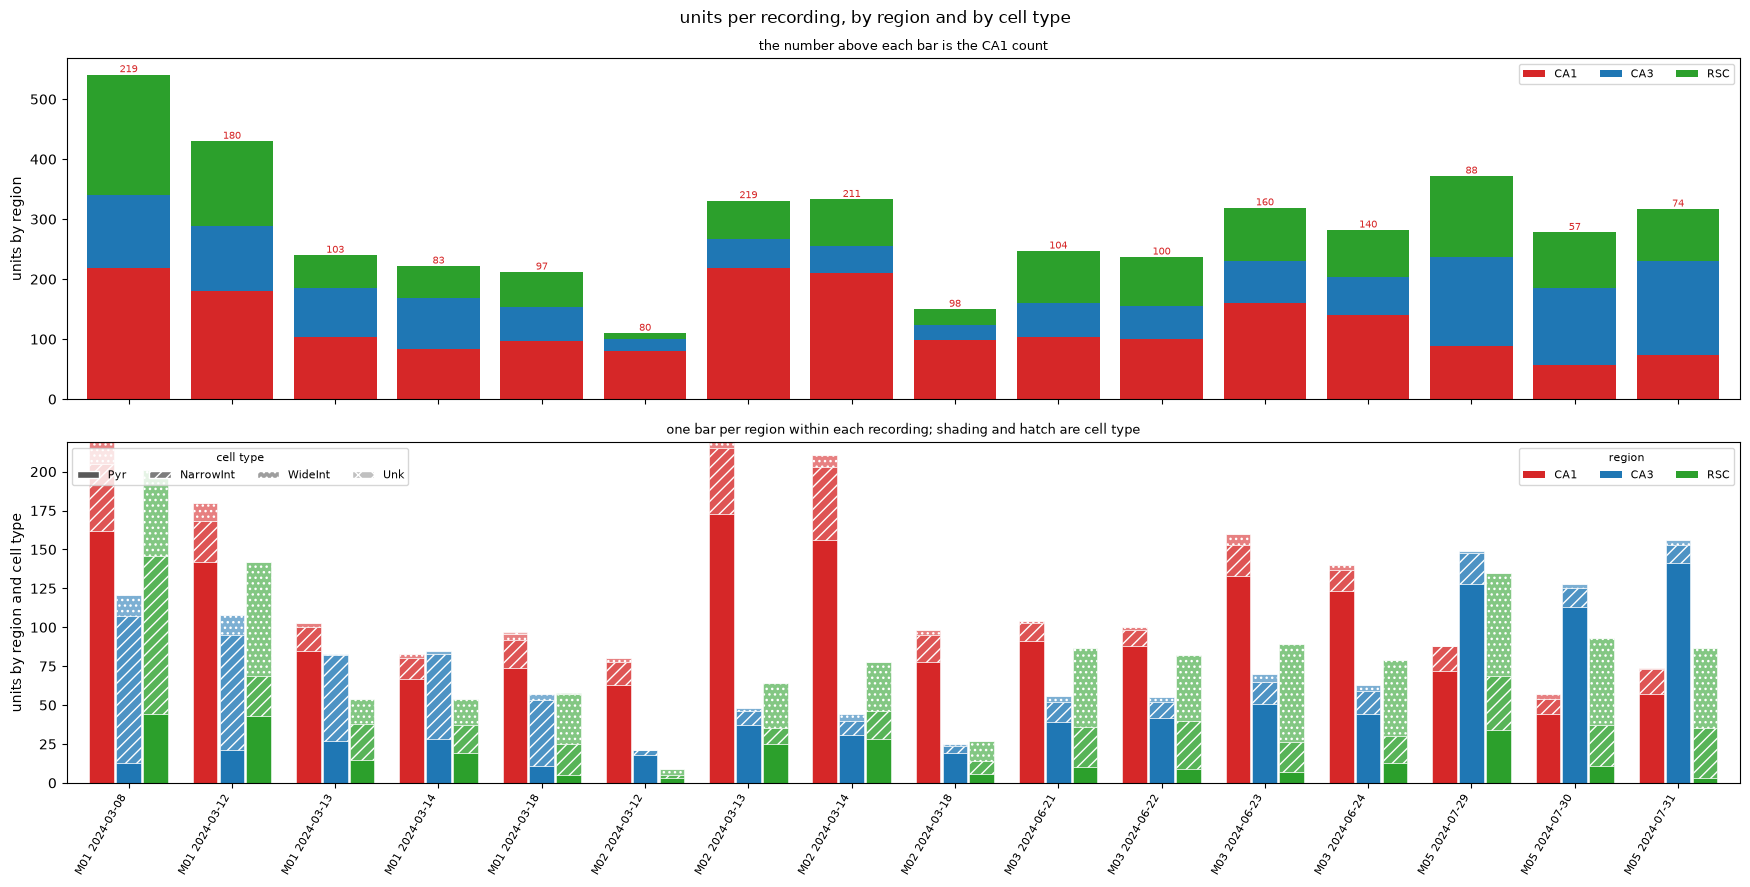


pick one and put it in RECORDING in CELL 3, e.g.
    RECORDING = "sub-M03_ses-20240623T100000_behavior+ecephys"


In [2]:
# %% ===========================================================================
# CELL 2 — survey the recordings and suggest one
# ==============================================================================
# Units per region and cell type for every file, and the ranking by how typical
# each recording's reconstruction is. Reads the unit table out of every NWB,
# which takes a few seconds per file and bins nothing.

print("=" * 78)
print("recording survey")
print("=" * 78)

recordings = recording_table()
print(f"{len(recordings)} recordings under {DOWNLOAD_DIR}")
units_long, units_wide = survey_units(recordings)

print("\nunits per recording, by region and cell type "
      "(Pyr = pyramidal, NarrowInt / WideInt = interneurons)")
show_table(units_wide)

print("\ntotals across recordings")
show_table(pd.concat([
    units_long.groupby(REGION_FIELD)["n"].agg(["sum", "mean", "min", "max"]),
    units_long.groupby(CELL_TYPE_FIELD)["n"].agg(["sum", "mean", "min", "max"]),
], keys=["region", "cell type"]).round(1))

scores = load_scores()
eligible = suggest_recordings(scores, recordings, units_long)
plot_unit_survey(units_long)

print("\npick one and put it in RECORDING in CELL 3, e.g.")
print(f'    RECORDING = "{Path(eligible["file"].iloc[0]).stem}"')




HDP-AR-HMM states against the cached manifold embeddings
RECORDING='sub-M03_ses-20240623T100000_behavior+ecephys' -> sub-M03/sub-M03_ses-20240623T100000_behavior+ecephys.nwb
loaded sub-M03/sub-M03_ses-20240623T100000_behavior+ecephys.nwb in 8.2s
    maze epoch 36.7 min | 317 units | 44056 bins at 50 ms | 2753522 LFP samples at 1250 Hz

units kept, by region and cell type


units
cell_area cell_type                
CA1       Narrow Interneuron     20
          Pyramidal Cell        131
          Wide Interneuron        7
CA3       Narrow Interneuron     14
          Pyramidal Cell         51
          Wide Interneuron        5
RSC       Narrow Interneuron     19
          Pyramidal Cell          7
          Wide Interneuron       63


LFP: Best_Ripple_channel_LFP_CA1 @ 1250 Hz
raw LFP held; run filter_bands() next

filtered 4 bands in 2.5s (raw envelope amplitude, before the spec's log or z-score)


,range_hz,median,mean,p95,sd
band,,,,,
low_theta,6-10,232.511,230.806,391.619,99.776
high_theta,10-12,68.931,77.435,164.484,46.753
gamma,30-90,138.451,160.269,361.390,103.028
ripple,120-200,34.455,38.770,83.100,23.854



embeddings from /storage/manifold_embeddings_zscoreddata
    PCA        44056 x 317, stride 1
    KernelPCA  4406 x 317, stride 10
    Laplacian  4406 x 317, stride 10
    common grid: 4406 bins (500 ms apart)


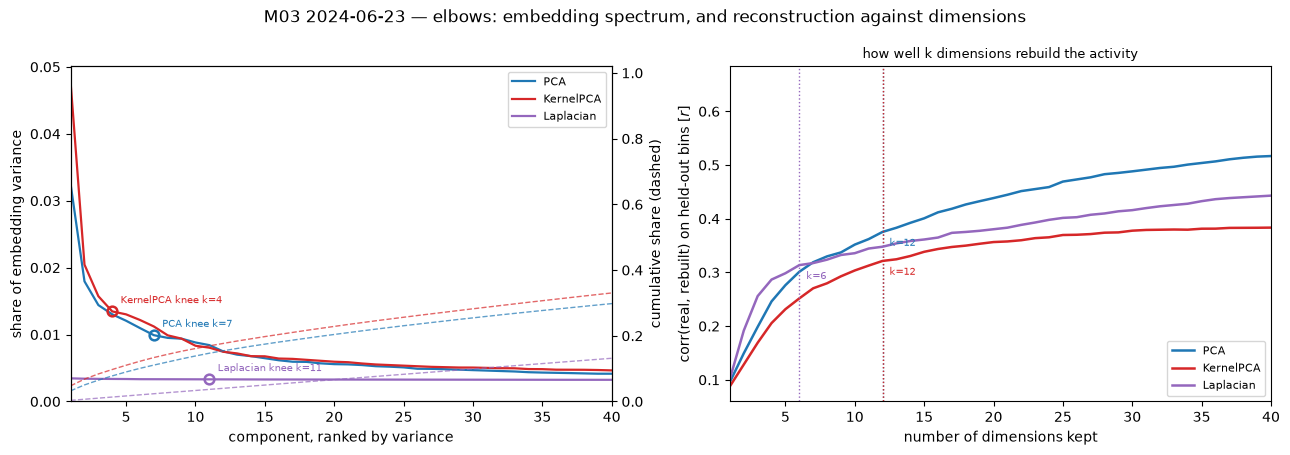


observations: 8 traces x 88112 samples at 40 Hz (10 lags x 25.0 ms = 250 ms of lag; LFP is 1250 Hz)


,kind,detail,mean,sd,min,max
observation,,,,,,
low_theta,band,"envelope, smooth=none, median per bin",-0.0,1.0,-2.306,4.307
high_theta,band,"envelope, smooth=none, median per bin",-0.0,1.0,-1.652,6.935
gamma,band,"envelope, smooth=none, median per bin",-0.0,1.0,-1.708,13.803
ripple,band,"envelope, smooth=none, median per bin",0.0,1.0,-1.932,30.049
MUA_CA3_Pyramidal Cell,mua,"51 units, 156069 spikes, norm=total_spikes, sm...",0.0,1.0,-0.978,10.641
MUA_CA3_Narrow Interneuron,mua,"14 units, 705457 spikes, norm=total_spikes, sm...",-0.0,1.0,-1.966,4.374
MUA_RSC_Pyramidal Cell,mua,"7 units, 59187 spikes, norm=total_spikes, smoo...",0.0,1.0,-0.930,7.328
MUA_RSC_Narrow Interneuron,mua,"19 units, 876665 spikes, norm=total_spikes, sm...",-0.0,1.0,-2.192,5.566


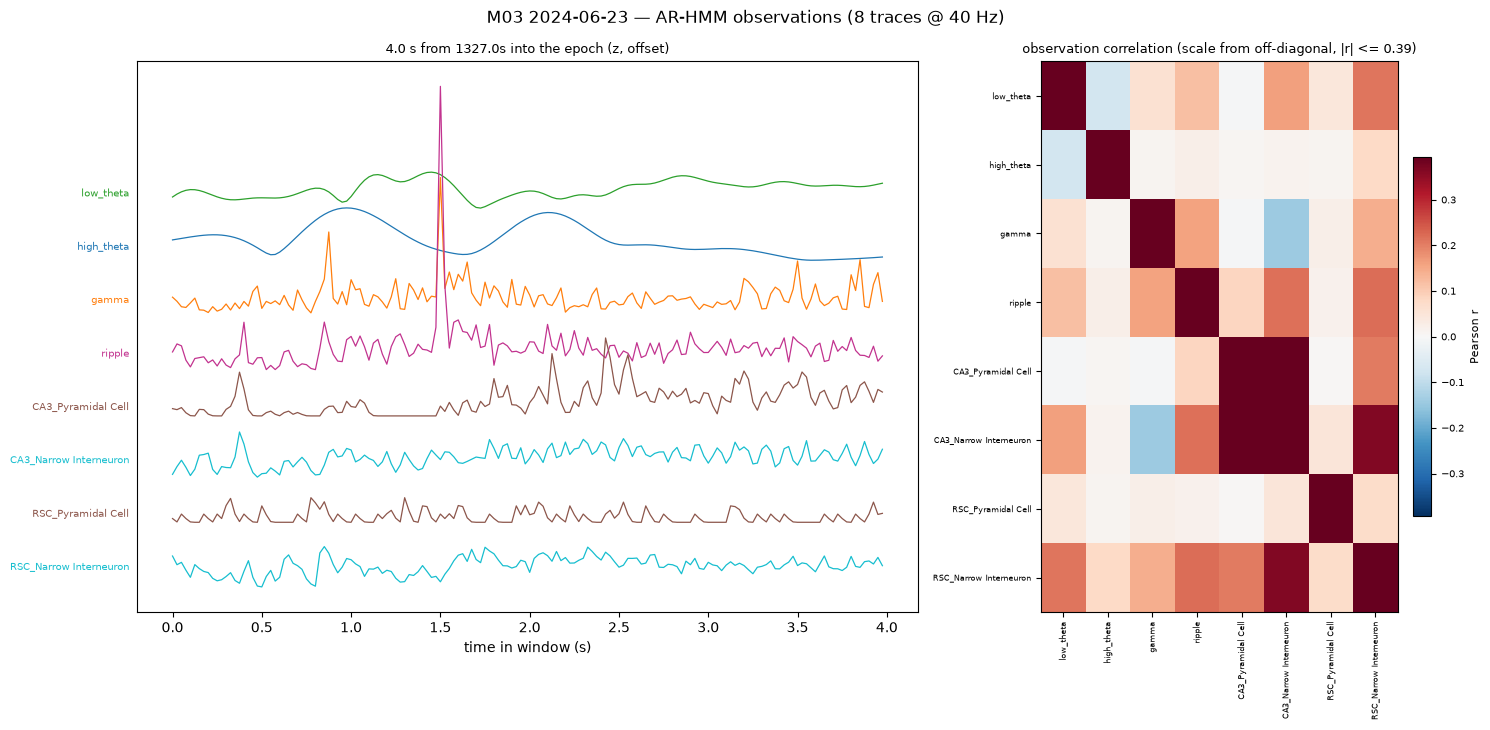


fitting the sticky HDP-AR-HMM
    observations: 8 traces — low_theta, high_theta, gamma, ripple, MUA_CA3_Pyramidal Cell, MUA_CA3_Narrow Interneuron, MUA_RSC_Pyramidal Cell, MUA_RSC_Narrow Interneuron
    10 segment(s), 24000 samples at 40 Hz (10.0 min, 27.2% of the epoch)
    placed at 136s, 322s, 522s, 704s, 930s, 1108s, 1334s, 1545s ...
    AR order 10 = 250 ms of lag | p = nlags*d+1 = 81 | L=20, kappa=50.0, <=60 iterations
    cost per iteration goes as samples x L x p^2
    iter    0/60 | used states 19 | log-lik     -90567.6 | 0.0 min spent, <=1.3 min left
    iter   10/60 | used states  4 | log-lik     -36283.8 | 0.2 min spent, <=0.9 min left
    iter   20/60 | used states  4 | log-lik     -36352.4 | 0.5 min spent, <=0.9 min left
    iter   30/60 | used states  4 | log-lik     -35812.1 | 0.7 min spent, <=0.6 min left
    iter   40/60 | used states  4 | log-lik     -36041.8 | 0.9 min spent, <=0.4 min left
    iter   50/60 | used states  4 | log-lik     -35702.8 | 1.2 min spent, <

,samples,occupancy_%,n_runs,median_dwell_ms,p90_dwell_ms,max_|eig|,oscillatory,speed_bins,speed_median
state,,,,,,,,,
0,20645,86.38,1219,275.0,1000.0,2.54,True,10936,1.12
1,1082,4.53,474,50.0,100.0,1.69,True,366,0.41
2,896,3.75,369,50.0,125.0,1.63,True,324,1.44
3,546,2.28,419,25.0,50.0,1.65,True,70,0.56



the observations by state (standardized; states across)


state 0        state 1        state 2        state 3  \
                          mean median    mean median    mean median    mean   
observation                                                                   
low_theta                 0.08   0.08   -0.92  -1.09   -0.01   0.00   -0.45   
high_theta                0.01  -0.18    0.34   0.14   -0.85  -1.02    0.14   
gamma                    -0.00  -0.21   -0.23  -0.36   -0.06  -0.22    0.28   
ripple                   -0.02  -0.16   -0.32  -0.41   -0.12  -0.27    1.22   
CA3_Pyramidal Cell       -0.07  -0.25   -0.34  -0.55   -0.01  -0.22    2.40   
CA3_Narrow Interneuron   -0.01  -0.04   -0.43  -0.56    0.01  -0.02    0.99   
RSC_Pyramidal Cell       -0.02  -0.09   -0.16  -0.43    0.62   0.02   -0.09   
RSC_Narrow Interneuron   -0.01  -0.04   -0.11  -0.20   -0.09  -0.11    0.46   

                               
                       median  
observation                    
low_theta               -0.54  
high_theta              -0.07  
gamma                   -0.08  
ripple                   0.53  
CA3_Pyramidal Cell       2.54  
CA3_Narrow Interneuron   0.98  
RSC_Pyramidal Cell      -0.43  
RSC_Narrow Interneuron   0.39

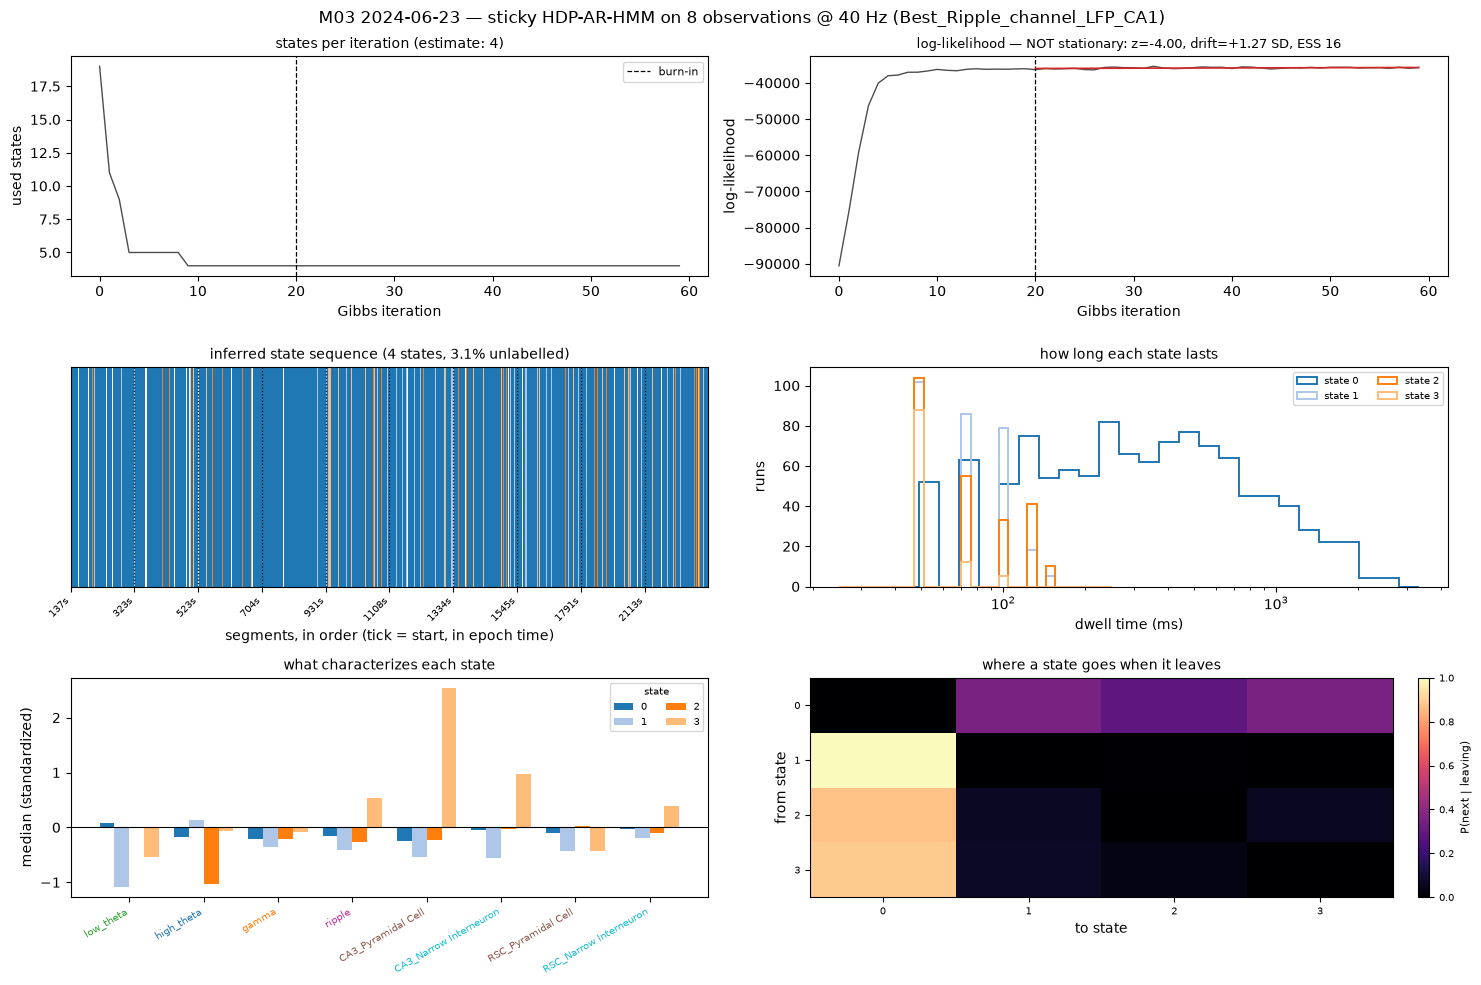


ranking components by variance (15 dims)
    PCA        top 3: #0 (0.0325), #1 (0.01795), #2 (0.01441) | 1s
    KernelPCA  top 3: #0 (0.0477), #1 (0.02045), #2 (0.01573) | 0s
    Laplacian  top 3: #10 (0.002968), #12 (0.002962), #14 (0.002944) | 0s


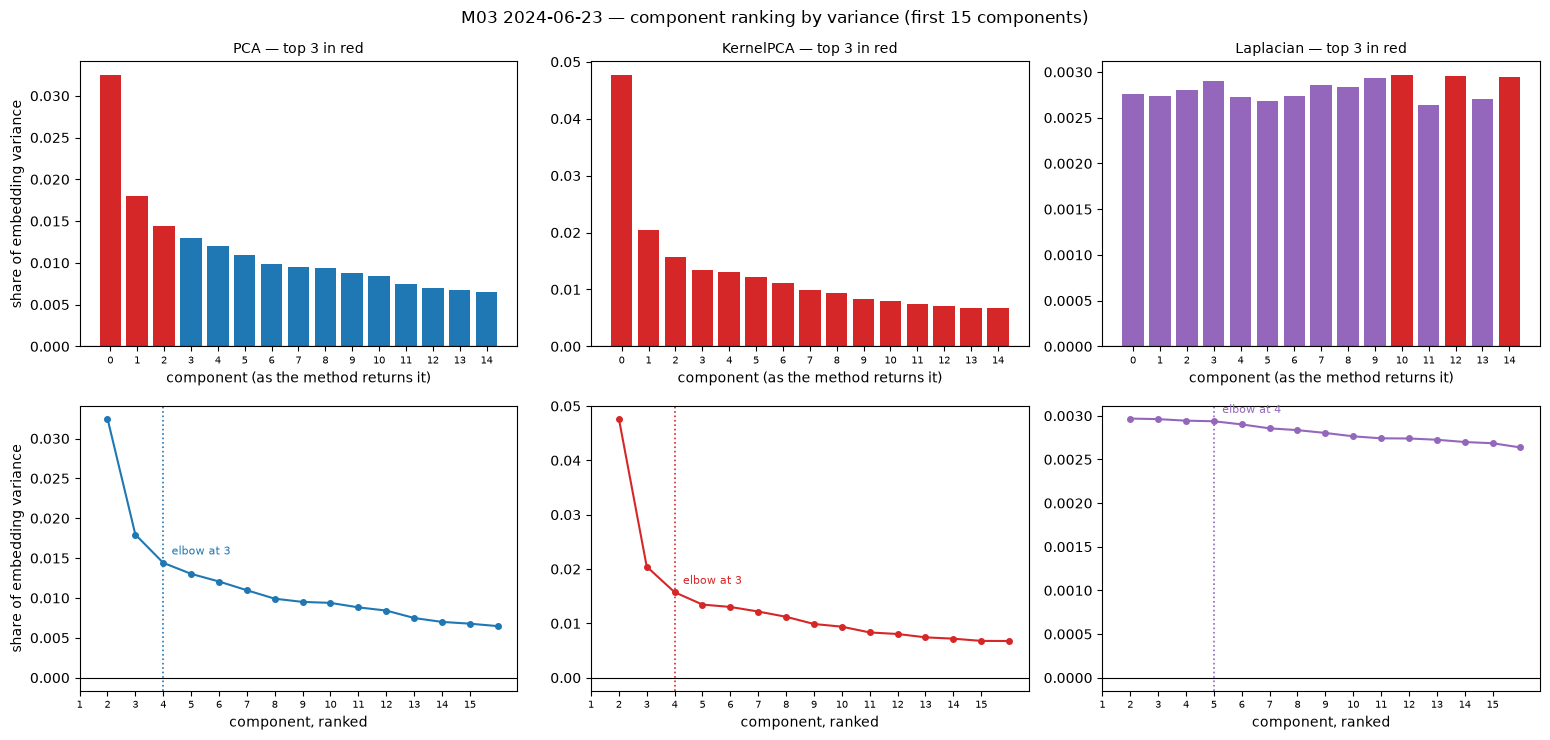

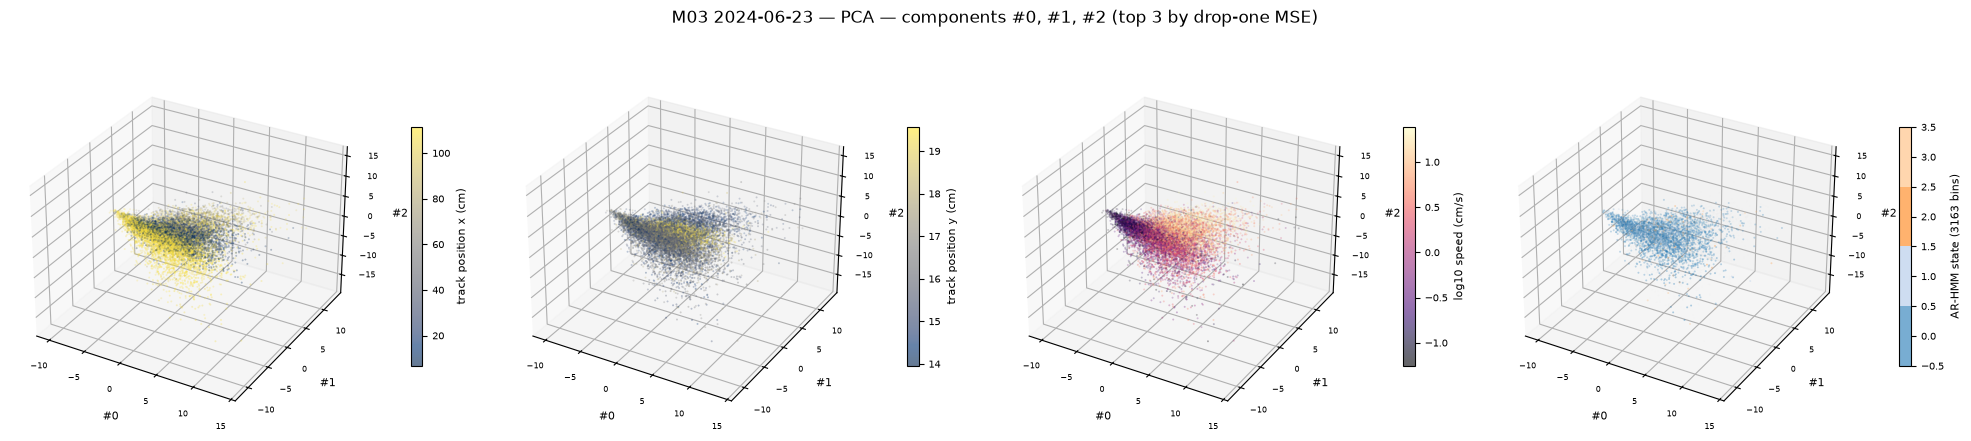

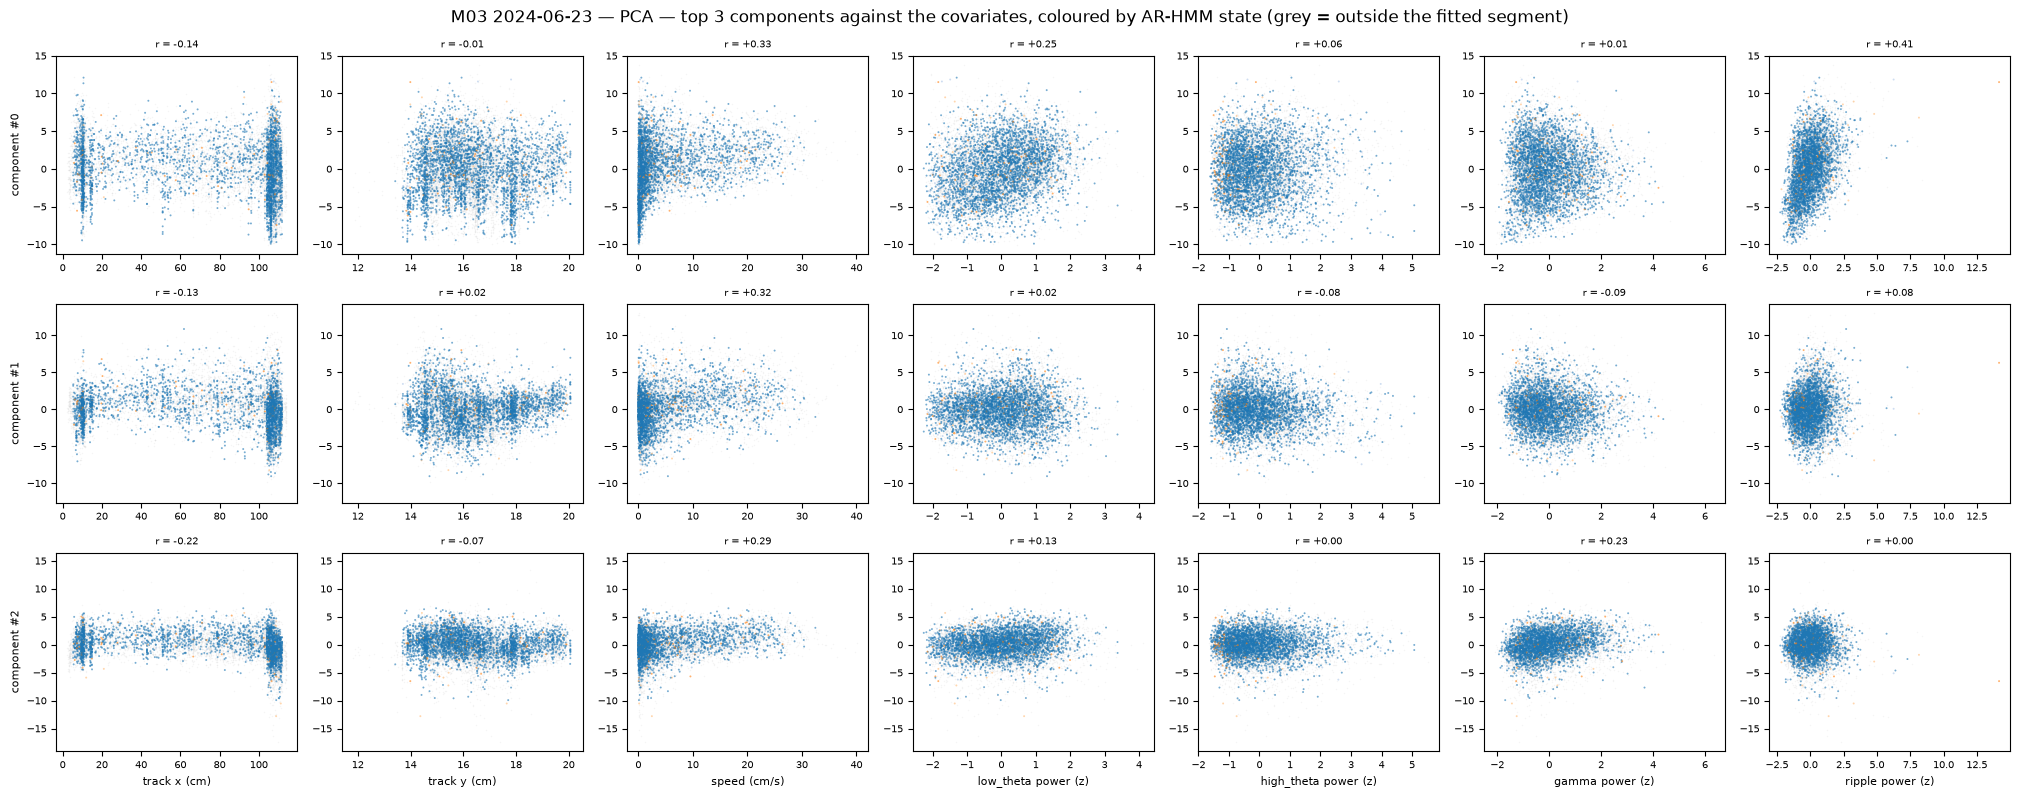

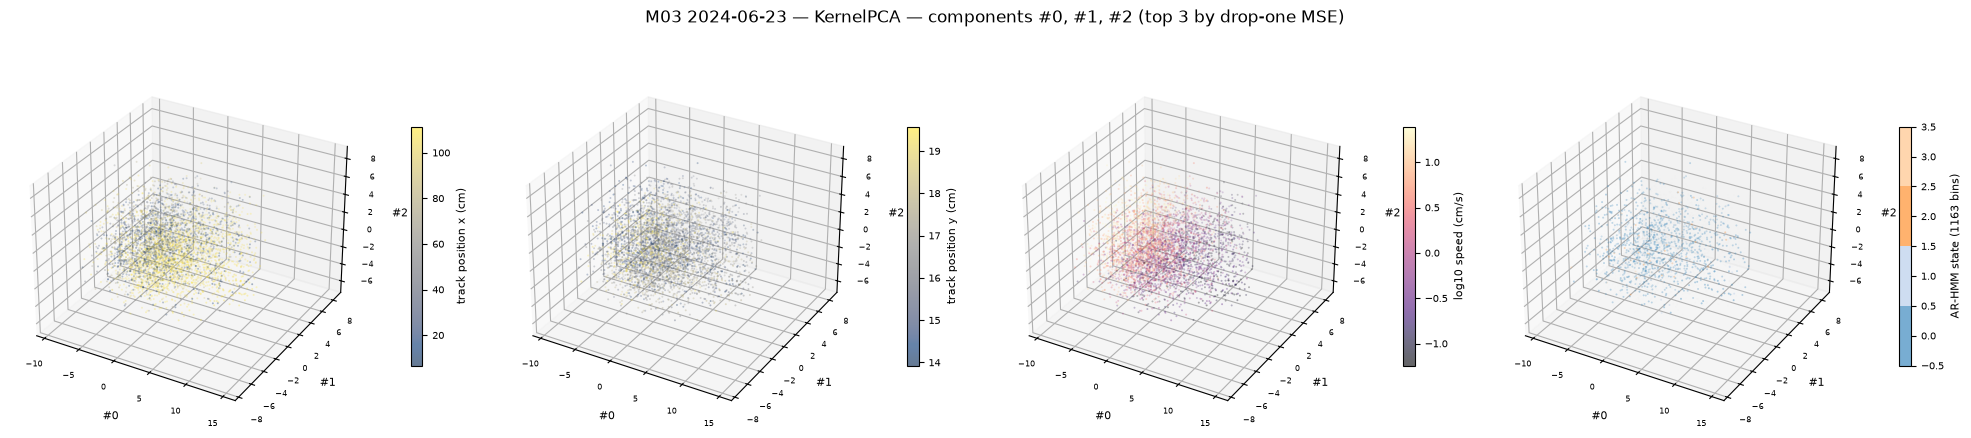

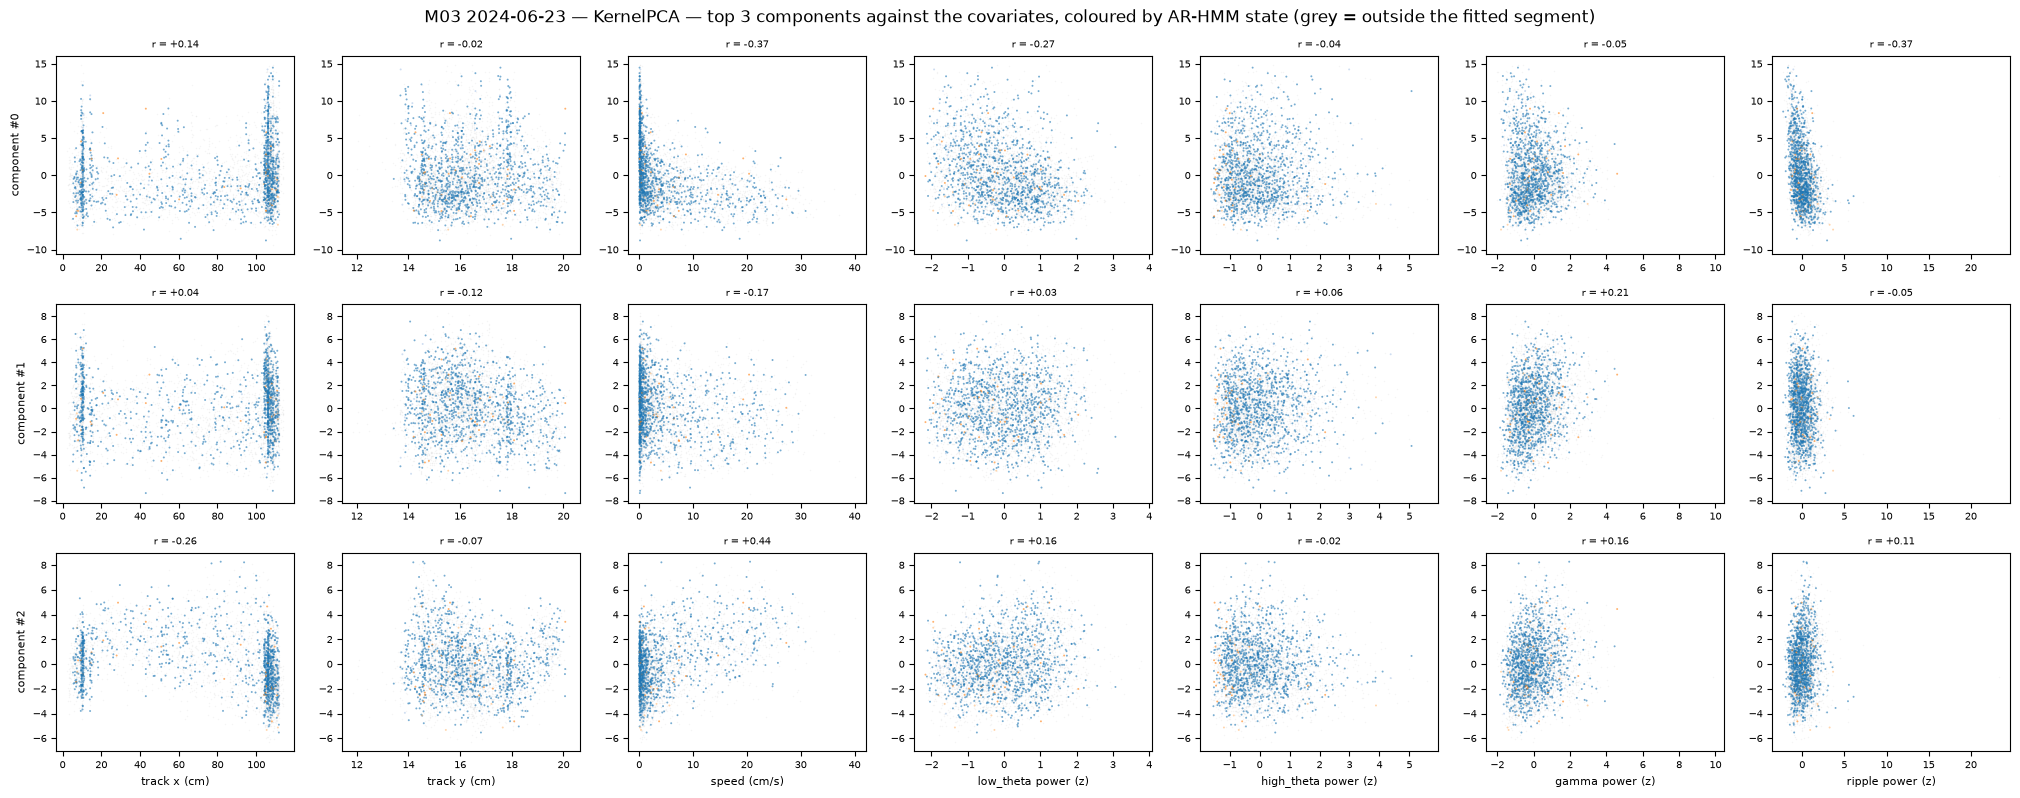

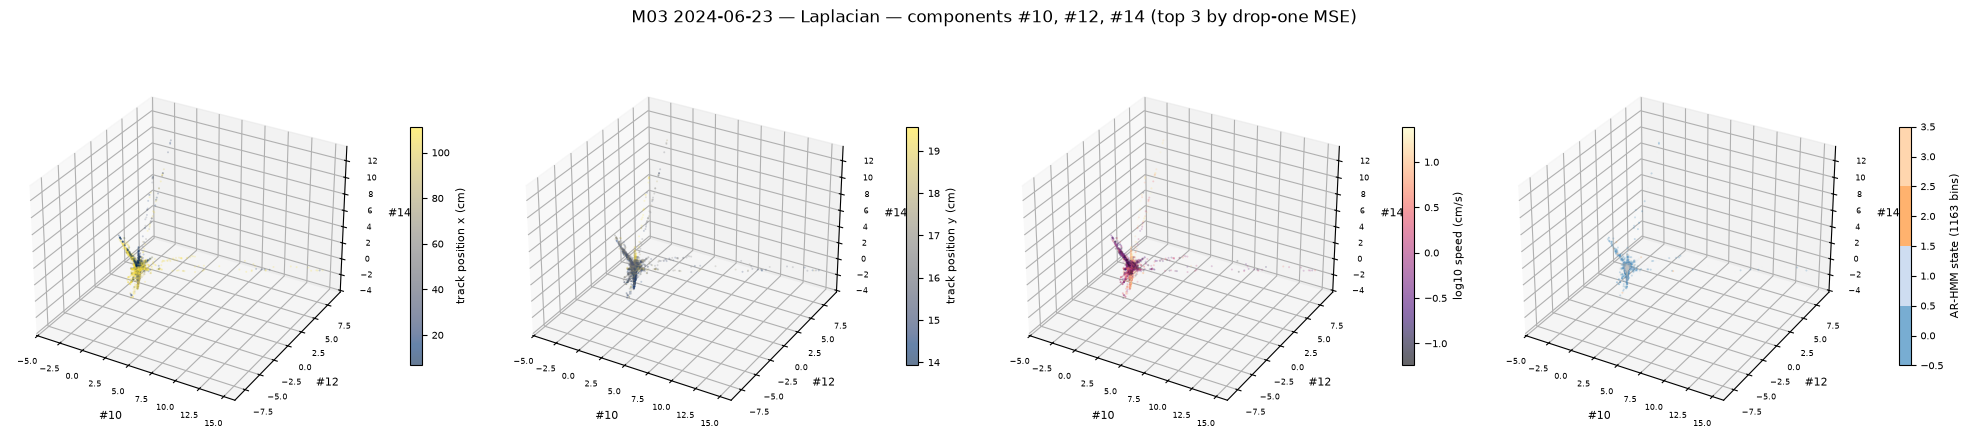

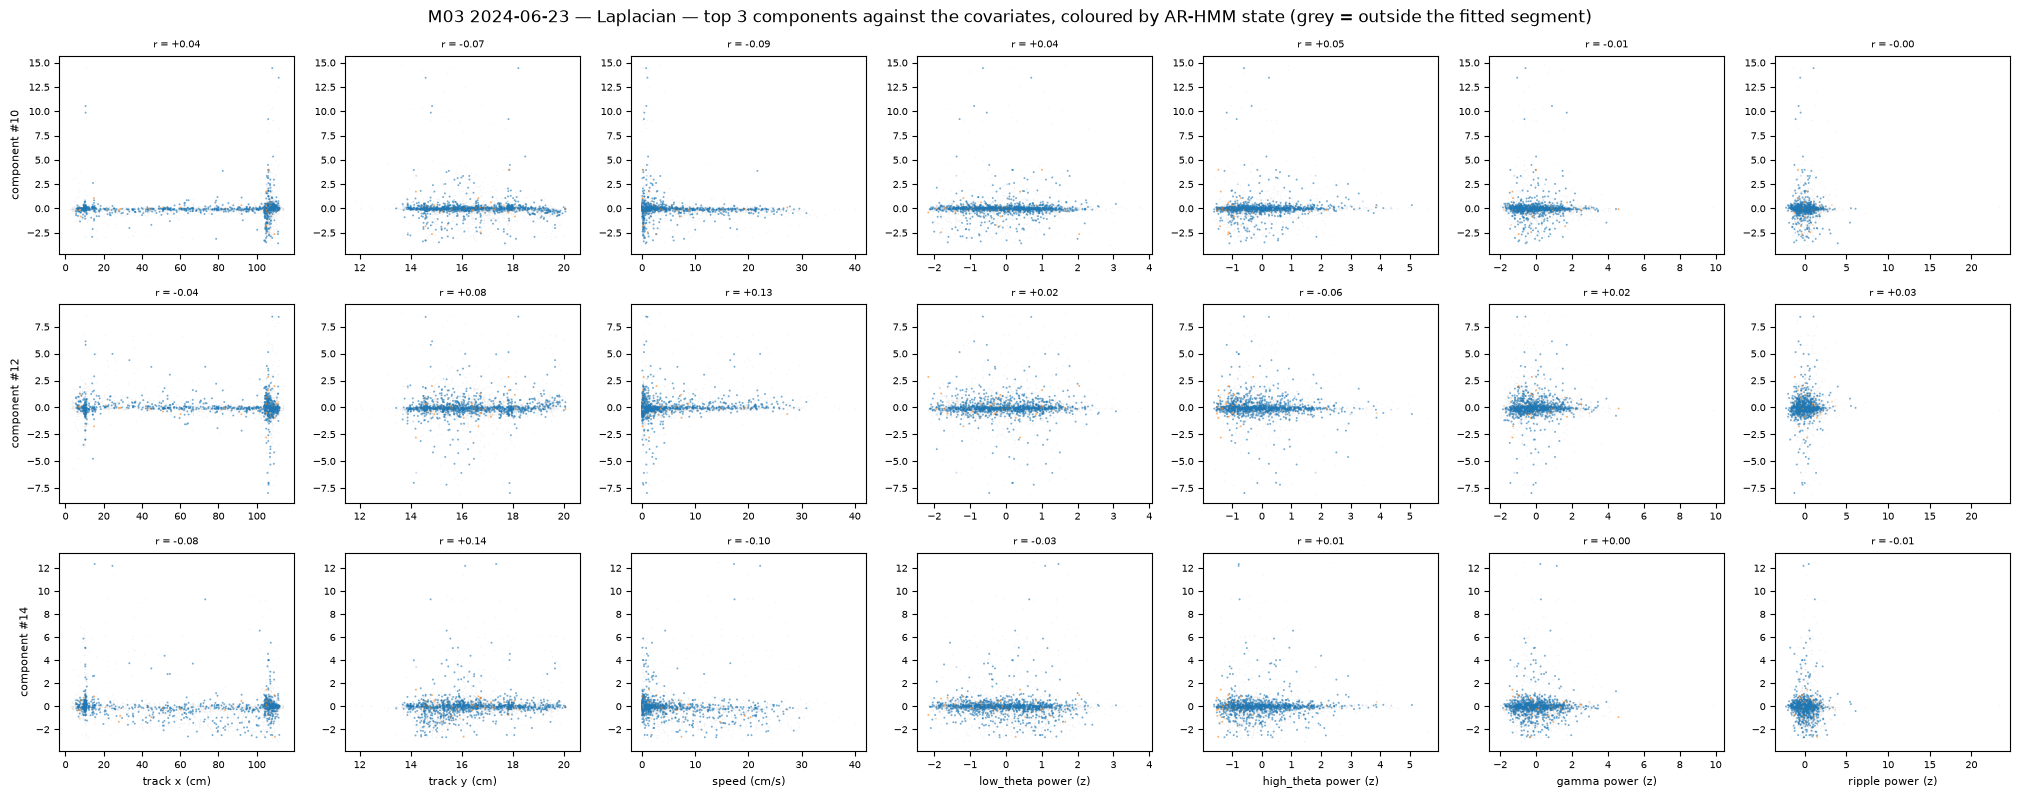


start_s is None — busiest window in any segment: 68 state changes starting 374.4s into the epoch


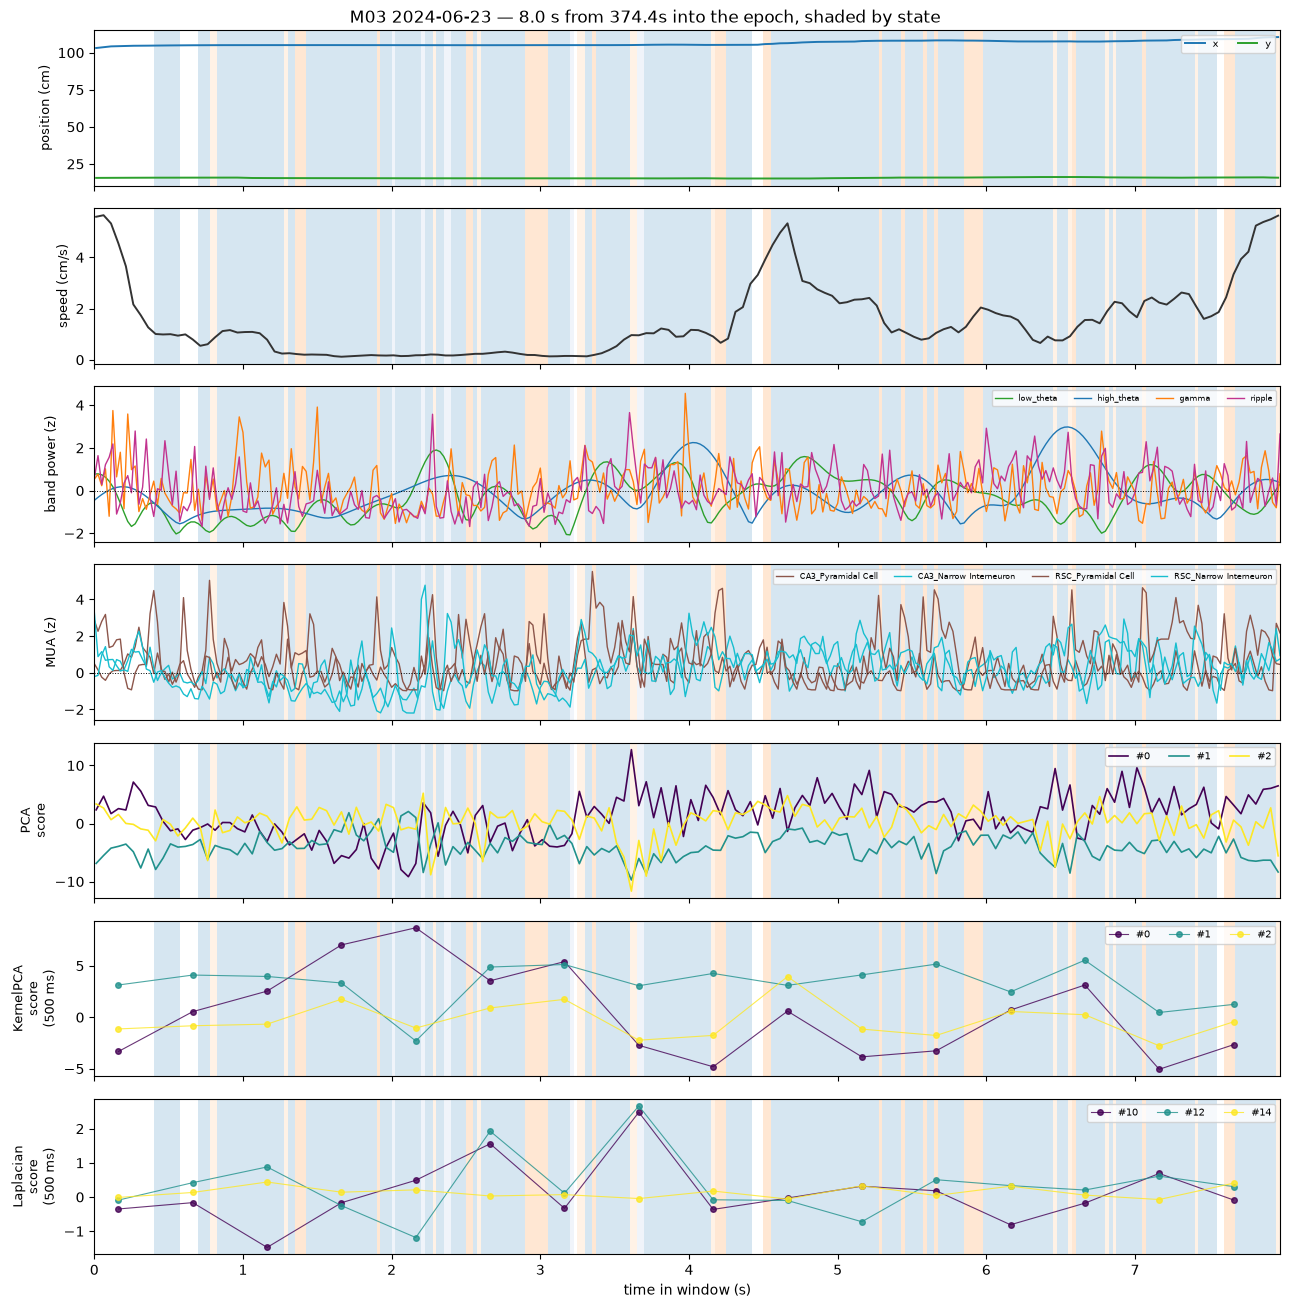

states in this window: [-1, 0, 1, 2, 3]


,occupancy_%,median_dwell_ms
state,,
0,86.38,275.0
1,4.53,50.0
2,3.75,50.0
3,2.28,25.0


,state 0,state 1,state 2,state 3
observation,,,,
low_theta,0.08,-1.09,0.00,-0.54
high_theta,-0.18,0.14,-1.02,-0.07
gamma,-0.21,-0.36,-0.22,-0.08
ripple,-0.16,-0.41,-0.27,0.53
CA3_Pyramidal Cell,-0.25,-0.55,-0.22,2.54
CA3_Narrow Interneuron,-0.04,-0.56,-0.02,0.98
RSC_Pyramidal Cell,-0.09,-0.43,0.02,-0.43
RSC_Narrow Interneuron,-0.04,-0.20,-0.11,0.39


In [3]:
# %% ===========================================================================
# CELL 3 — one recording, end to end
# ==============================================================================
# Everything that changes between runs is here. OBS_SPEC is what the AR-HMM is
# trained on — change it, re-run this cell, look at plot_observations, repeat.
# The session is loaded once and holds the raw ingredients, so rebuilding the
# observations under a new spec costs seconds and does not re-read the file.
# build_observations() documents every key.
#
# Runtime is RUN_MINUTES x n_lags^3 / lag_span_s. More lags across the same
# span costs in both the sample count and the regression width.

RECORDING = "sub-M03_ses-20240623T100000_behavior+ecephys"   # substring of the file, from CELL 2

# Everything the AR-HMM is trained on, written out. Edit the frequencies, add
# or delete a band, name the regions and cell types you want, then re-run the
# cell. Nothing here points back at CELL 1.
#
# As set: band envelopes with no extra smoothing (the Hilbert envelope is
# already the smoothing of the band), z-scored; plus the MUA of every listed
# region x cell type with at least 3 units, on a causal 20 ms kernel.
OBS_SPEC = {
    # The AR lags reach back lag_span_s in total, in n_lags steps. One step is
    # lag_span_s / n_lags, and that is the grid everything is built on. The
    # LFP is recorded at 1250 Hz, so asking for a step shorter than 0.8 ms is
    # an error. Cost goes as (n_lags * n_observations)^2.
    "lag_span_s": 0.25,
    "n_lags": 10,
    "bin_method": "median",   # per bin, for bands: median | mean | max | sum

    "bands": {
        "use": True,
        # name: (low Hz, high Hz). The only clear peak on this channel is
        # theta, sitting high, so it is split into a low and a high half.
        "bands": {
            "low_theta": (6.0, 10.0),
            "high_theta": (10.0, 12.0),
            "gamma": (30.0, 90.0),
            "ripple": (120.0, 200.0),
        },
        "measure": "envelope",   # "envelope" | "power" | "filtered"
        "smooth": None,          # or {"kind": "half_gaussian", "sigma_s": 0.01}
        "transform": None,       # None | "log1p" | "log10"
        "zscore": True,
    },

    "mua": {
        "use": True,
        # One pooled trace per (region, cell type) pair listed. Comment out
        # any line to drop just that pair — asking for CA1 pyramidal without
        # CA1 interneurons is a matter of deleting the line. None here means
        # every pair the recording has. A pair it lacks is an error.
        "groups": [
            #("CA1", "Pyramidal Cell"),
            #("CA1", "Narrow Interneuron"),
            #("CA1", "Wide Interneuron"),
            ("CA3", "Pyramidal Cell"),
            ("CA3", "Narrow Interneuron"),
            #("CA3", "Wide Interneuron"),
            ("RSC", "Pyramidal Cell"),
            ("RSC", "Narrow Interneuron"),
            #("RSC", "Wide Interneuron"),
        ],
        "min_units": 3,          # smaller pairs are reported, not used
        # counts in each bin divided by that population's own spike total, so
        # each column is the share of its spikes per bin and empty bins are 0
        "normalize": "total_spikes",   # or None for spikes per second
        # causal, so a population's rise is dated to when it happened
        "smooth": {"kind": "half_gaussian", "sigma_s": 0.020},
        "transform": "log1p",    # None | "log1p" | "log10"
        "zscore": True,
    },
}

# Segments are placed one per equal block of the recording at a random offset,
# so this is 10 min from across the session, not 10 min of one corner.
# RUN_START_S as a number takes a single contiguous window there instead.
RUN_MINUTES = 10.0
RUN_SEGMENT_S = 60.0
RUN_SEGMENT_SEED = 0
RUN_START_S = None


# The run stops once the retained log-likelihood looks stationary, so
# RUN_MAX_ITER is a ceiling rather than a target. Failing to get there prints
# a warning with the three diagnostics and keeps going with what it has.
# RUN_BURN_IN must be below RUN_MAX_ITER, and the first stationarity check
# needs 2 x RUN_CHECK_EVERY retained iterations before it can fire.
RUN_MAX_ITER = 60
RUN_BURN_IN = 20
RUN_EARLY_STOP = True
RUN_CHECK_EVERY = 10          # how often stationarity is tested, and reported
RUN_GEWEKE_TOL = 2.0          # |z| below this counts as stationary

RUN_KAPPA = 50.0              # sticky bias: bigger = longer dwell times
RUN_L = 20                    # truncation; raise it if K_hat lands on L-1
RUN_WINDOW_S = 8.0
RUN_WINDOW_START_S = None     # None = the busiest window in the segment
RUN_METHODS = ("PCA", "KernelPCA", "Laplacian")

# How components are ordered, and so which three the manifold figures draw.
#   "variance"      each component's share of the embedding's variance. For
#                   PCA and kernel PCA this is the eigenvalue spectrum. Free.
#   "drop_one_mse"  the increase in held-out reconstruction MSE when that
#                   component is removed. A different question, and minutes
#                   per method rather than instant.
RUN_RANK_BY = "variance"

print("=" * 78)
print("HDP-AR-HMM states against the cached manifold embeddings")
print("=" * 78)

# 1. the recording: the sweep's 50 ms grid, the behaviour, the raw LFP and the
#    pooled spike times. No filtering yet.
row = resolve_recording(recordings, RECORDING)
session = load_session(row)

# 2. bandpass the raw LFP at the frequencies OBS_SPEC names. Re-run this after
#    changing a range and it refilters from the raw trace — no reload.
session = filter_bands(session, OBS_SPEC["bands"]["bands"])

# 3. the embeddings the sweep already computed
embeddings, common_idx = load_embeddings(session)

# 4. elbows: the embedding spectra, and this recording's own recovery curve
plot_elbows(session, embeddings, scores)

# 5. build the observations from OBS_SPEC and look at them before fitting
obs = build_observations(session, OBS_SPEC)
plot_observations(session, obs)

# 6. the AR-HMM, at the observation grid's own rate
fit = fit_states(session, obs, minutes=RUN_MINUTES, segment_s=RUN_SEGMENT_S,
                 segment_seed=RUN_SEGMENT_SEED, start_s=RUN_START_S,
                 nlags=OBS_SPEC["n_lags"],
                 max_iter=RUN_MAX_ITER, burn_in=RUN_BURN_IN,
                 stop_when_stationary=RUN_EARLY_STOP,
                 check_every=RUN_CHECK_EVERY, geweke_tol=RUN_GEWEKE_TOL,
                 kappa=RUN_KAPPA, L=RUN_L)
state_table = state_characterization(session, fit)
plot_arhmm(session, fit, state_table)

# 7. order the components, and take the top three into the figures below
ranking, rank_table = rank_components(session, embeddings, by=RUN_RANK_BY)
plot_ranking(session, rank_table)

# 8. the manifolds and the components, against behaviour and band power
for method in RUN_METHODS:
    plot_manifold(session, embeddings, fit, ranking, method)
    plot_covariates(session, embeddings, fit, ranking, method)

# 9. one window with everything on a shared time axis
plot_example_window(session, embeddings, fit, ranking, state_table,
                    start_s=RUN_WINDOW_START_S, window_s=RUN_WINDOW_S,
                    methods=RUN_METHODS)
